In [1]:
# --- Interactive Environment ---
%matplotlib inline

# --- Standard Library ---
import os
import re
import glob
import json
import pickle
from pathlib import Path
from datetime import datetime
from typing import Sequence, Optional, Tuple, Dict, Union
from dataclasses import dataclass
from itertools import combinations

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colormaps
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.stats import linregress, mannwhitneyu, spearmanr, pearsonr, wilcoxon, binomtest, norm, fisher_exact
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler

# --- Local / Project Imports ---
from aind_dynamic_foraging_basic_analysis.licks.lick_analysis import load_nwb
from aind_analysis_arch_result_access.han_pipeline import get_mle_model_fitting
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_analysis import (
    get_session_name_from_path,
    session_already_done,
)
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_kinematics_utils import (
    annotate_movement_timing,
    add_lick_metadata_to_movements,
)
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import (
    get_events_dict, 
    build_event_df, 
    plot_unit_panels, 
    RasterPlotter, 
    compute_psth, 
    smooth_vector, 
    plot_psth,
    find_session_dir,
    load_intermediate_data,
    get_session_prefix,
    )


In [2]:
#load ephys data
with open('/root/capsule/scratch/combined_unit_tbl.pkl', 'rb') as file:
    combined_ephys_data = pickle.load(file)

In [3]:
from pathlib import Path
import json
import pandas as pd

# ---- criteria ----
COVERAGE_MIN = 90.0
DURATION50_MIN = 0.06  # seconds

# # ---- roots to scan ----
# base_dirs = [
#     Path("/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_OOD"),
#     Path("/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_ID"),
# ]

base_dirs = [Path("/root/capsule/scratch/session_analysis_mlk")]

rows_pass = []
rows_fail = []

for base_dir in base_dirs:
    if not base_dir.exists():
        continue
    for subdir in base_dir.iterdir():
        if not (subdir.is_dir() and session_already_done(subdir)):
            continue

        json_file = subdir / "tongue_quality_stats.json"
        try:
            with open(json_file, "r") as f:
                d = json.load(f)
        except Exception as e:
            print(f"Skipping {subdir} (couldn't read JSON): {e}")
            continue

        cov = float(d.get("coverage_pct", 0.0))
        dur50 = float(d.get("percentiles", {}).get("duration", {}).get("0.5", 0.0))

        row = {
            "session_path": subdir,
            "json_path": json_file,
            "session_id": d.get("session_id", subdir.name),
            "coverage_pct": cov,
            "duration_p50": dur50,
        }

        if cov > COVERAGE_MIN and dur50 > DURATION50_MIN:
            rows_pass.append(row)
        else:
            rows_fail.append(row)

# ---- results: sessions meeting criteria ----
filtered_df = pd.DataFrame(rows_pass).sort_values(
    ["coverage_pct", "duration_p50"], ascending=[False, False]
)

print(
    f"Sessions meeting criteria (coverage>{COVERAGE_MIN}, "
    f"median duration>{DURATION50_MIN}s): {len(filtered_df)}"
)
for _, r in filtered_df.iterrows():
    print(
        f"{r['session_path']}  "
        f"(coverage={r['coverage_pct']:.1f}%, median_dur={r['duration_p50']:.3f}s)"
    )

filtered_session_paths = filtered_df["session_path"].tolist()

# ---- results: sessions NOT meeting criteria ----
failed_df = pd.DataFrame(rows_fail).sort_values(
    ["coverage_pct", "duration_p50"], ascending=[False, False]
)

print(
    f"\nSessions NOT meeting criteria "
    f"(coverage<={COVERAGE_MIN} or median duration<={DURATION50_MIN}s): {len(failed_df)}"
)
for _, r in failed_df.iterrows():
    print(
        f"{r['session_path']}  "
        f"(coverage={r['coverage_pct']:.1f}%, median_dur={r['duration_p50']:.3f}s)"
    )


Sessions meeting criteria (coverage>90.0, median duration>0.06s): 44
/root/capsule/scratch/session_analysis_mlk/behavior_782394_2025-04-23_10-51-14  (coverage=100.0%, median_dur=0.074s)
/root/capsule/scratch/session_analysis_mlk/behavior_782394_2025-04-24_12-07-31  (coverage=100.0%, median_dur=0.072s)
/root/capsule/scratch/session_analysis_mlk/behavior_782394_2025-04-25_11-13-18  (coverage=100.0%, median_dur=0.072s)
/root/capsule/scratch/session_analysis_mlk/behavior_761038_2025-04-15_10-24-57  (coverage=99.9%, median_dur=0.074s)
/root/capsule/scratch/session_analysis_mlk/behavior_791691_2025-06-27_13-54-27  (coverage=99.9%, median_dur=0.068s)
/root/capsule/scratch/session_analysis_mlk/behavior_752014_2025-03-28_11-04-56  (coverage=99.9%, median_dur=0.092s)
/root/capsule/scratch/session_analysis_mlk/behavior_751769_2025-01-16_11-31-52  (coverage=99.8%, median_dur=0.076s)
/root/capsule/scratch/session_analysis_mlk/behavior_716325_2024-05-31_10-31-14  (coverage=99.8%, median_dur=0.090s)


In [4]:

#filter units by session and quality criteria

DEFAULT_CRITERIA = {
    "isi_violations": {"bounds": [0.0, 0.1]},
    "p_max":         {"bounds": [0.5, 1.0]},
    "lat_max_p":     {"bounds": [0.005, 0.02]},
    "eu":            {"bounds": [0.0, 0.25]},
    "corr":          {"bounds": [0.95, 1.0]},
    "qc_pass":       {"items":  [True]},
    "peak":          {"bounds": [-1000, 0]},
    "trial_count":   {"bounds": [100, 2000]},
    "in_df":         {"items":  [True]},
}

def filter_by_criteria(df: pd.DataFrame, criteria: dict = None) -> pd.DataFrame:
    if criteria is None:
        criteria = DEFAULT_CRITERIA
    mask = pd.Series(True, index=df.index)
    for col, rule in criteria.items():
        if "bounds" in rule:
            lo, hi = rule["bounds"]
            mask &= df[col].between(lo, hi, inclusive="both")
        if "items" in rule:
            mask &= df[col].isin(rule["items"])
    return df.loc[mask].copy()

# =========================
# 1) get session ids
# =========================
# done_sessions should already be defined
session_order_full   = [get_session_name_from_path(str(p)) for p in filtered_session_paths]
session_prefix_order = [get_session_prefix(s) for s in session_order_full]
session_prefix_allow = set(session_prefix_order)

# =========================
# 2) filter ephys
# =========================
# ensure session_prefix exists on both tables
combined_ephys_data = combined_ephys_data.copy()
combined_ephys_data["session_prefix"] = combined_ephys_data["session"].map(get_session_prefix)

criteria_filtered = filter_by_criteria(combined_ephys_data, DEFAULT_CRITERIA)

# final filtered units = criteria + allowed session prefixes
filtered_ephys = criteria_filtered.loc[
    criteria_filtered["session_prefix"].isin(session_prefix_allow)
].copy()

# =========================
# 3) session summary
# =========================
counts_before = combined_ephys_data.groupby("session_prefix").size().rename("units_before")
counts_after  = criteria_filtered.groupby("session_prefix").size().rename("units_after")

base = pd.concat([counts_before, counts_after], axis=1).reindex(session_prefix_order)
base["units_before"] = base["units_before"].astype("Int64")        # keep NA if not present before
base["units_after"]  = base["units_after"].fillna(0).astype(int)   # 0 if none survived

session_summary = base.reset_index().rename(columns={"index": "session_prefix"})

# =========================
# prints / outputs
# =========================
print(f"Filtered units: {len(filtered_ephys)} / {len(combined_ephys_data)}")
print(session_summary.to_string(index=False))

# =========================
# QC-only vs session-filtered counts
# =========================
n_qc_all_sessions = len(criteria_filtered)
n_qc_allowed_sessions = len(filtered_ephys)
n_excluded_by_session = n_qc_all_sessions - n_qc_allowed_sessions

print(
    f"QC-pass units (all sessions): {n_qc_all_sessions}\n"
    f"QC-pass units (allowed sessions only): {n_qc_allowed_sessions}\n"
    f"QC-pass units excluded by session filter: {n_excluded_by_session}"
)



Filtered units: 104 / 18300
            session_prefix  units_before  units_after
behavior_782394_2025-04-23           243            9
behavior_782394_2025-04-24           394            7
behavior_782394_2025-04-25           116            0
behavior_761038_2025-04-15           435            2
behavior_791691_2025-06-27           265            4
behavior_752014_2025-03-28           254            1
behavior_751769_2025-01-16           229            1
behavior_716325_2024-05-31           281            3
behavior_758017_2025-02-06           127            1
behavior_782394_2025-04-22           270            0
behavior_758017_2025-02-07           231            4
behavior_751769_2025-01-18           255            5
behavior_754897_2025-03-14           117            5
behavior_784803_2025-07-01           357            3
behavior_784803_2025-07-02           375            0
behavior_751004_2024-12-20           248            3
behavior_751766_2025-02-11           277            5


In [5]:
ROOT_SCRATCH = "/root/capsule/data/LC-NE_scratch_data_1"

os.path.exists(ROOT_SCRATCH), os.path.isdir(ROOT_SCRATCH)


(True, True)

In [6]:
#load individual ephys data with spike times

ROOT_SCRATCH = "/root/capsule/data/LC-NE_scratch_data_1"

def get_animal_id(session: str) -> str:
    m = re.match(r'^behavior_(\d+)_', session)
    if not m:
        raise ValueError(f"Cannot parse animal id from session: {session}")
    return m.group(1)

def find_summary_pkl(root: str, session: str) -> Optional[Path]:  # <-- fixed
    """Try exact path; if missing, fall back to prefix glob search."""
    animal = get_animal_id(session)
    exact = Path(root) / animal / session / "ephys" / "opto" / "curated" / f"{session}_curated_soma_opto_tagging_summary.pkl"
    if exact.exists():
        return exact
    pref = get_session_prefix(session)
    candidates = list((Path(root) / animal).glob(f"{pref}_*/ephys/opto/curated/*_curated_soma_opto_tagging_summary.pkl"))
    return candidates[0] if candidates else None

# ---- main loop (same as before) ----
units_with_spikes = []
for session, subdf in filtered_ephys.groupby("session"):
    pkl_path = find_summary_pkl(ROOT_SCRATCH, session)
    if pkl_path is None:
        print(f"[skip] No summary .pkl found for {session}")
        continue

    with open(pkl_path, "rb") as f:
        ephys_session_data = pickle.load(f)
    if not isinstance(ephys_session_data, pd.DataFrame):
        try:
            ephys_session_data = pd.DataFrame(ephys_session_data)
        except Exception:
            print(f"[skip] Summary not a DataFrame for {session}")
            continue

    unit_ids = subdf["unit"].unique()
    ephys_data = (
        ephys_session_data[ephys_session_data["unit_id"].isin(unit_ids)]
        .copy()
        .assign(session=session)
    )
    print(f"[ok] {session}: {len(ephys_data)}/{len(unit_ids)} units with 'spike_times' column")
    units_with_spikes.append(ephys_data)

units_with_spikes = (
    pd.concat(units_with_spikes, ignore_index=True)
    if units_with_spikes else pd.DataFrame(columns=["session","unit_id","spike_times"])
)
print("Final units_with_spikes shape:", units_with_spikes.shape)


[ok] behavior_716325_2024-05-31_10-31-14: 3/3 units with 'spike_times' column
[ok] behavior_751004_2024-12-20_13-26-11: 3/3 units with 'spike_times' column
[ok] behavior_751004_2024-12-21_13-28-28: 3/4 units with 'spike_times' column
[ok] behavior_751004_2024-12-22_13-09-17: 1/1 units with 'spike_times' column
[ok] behavior_751004_2024-12-23_14-20-03: 2/2 units with 'spike_times' column
[ok] behavior_751181_2025-02-25_12-12-35: 2/2 units with 'spike_times' column
[ok] behavior_751181_2025-02-27_11-24-47: 5/5 units with 'spike_times' column
[ok] behavior_751766_2025-02-11_11-53-38: 5/5 units with 'spike_times' column
[ok] behavior_751766_2025-02-13_11-31-21: 3/3 units with 'spike_times' column
[ok] behavior_751766_2025-02-14_11-37-11: 4/4 units with 'spike_times' column
[ok] behavior_751769_2025-01-16_11-32-05: 1/1 units with 'spike_times' column
[ok] behavior_751769_2025-01-17_11-37-39: 3/3 units with 'spike_times' column
[ok] behavior_751769_2025-01-18_10-15-25: 5/5 units with 'spike_

In [7]:
# ---------- config ----------

@dataclass
class AnalysisConfig:
    align_key: str = "goCue"
    count_window_s: Tuple[float,float] = (0.0, 0.100)
    min_trials_per_group: int = 8
    only_cue_response_trials: bool = True
    latency_window_s: Optional[Tuple[float,float]] = None
    baseline_window_s: Optional[Tuple[float,float]] = None

# ---------- tiny utils ----------
def first_spike_latency_in_window(
    spike_times_sorted: np.ndarray, t0: float, window: Tuple[float, float]) -> Tuple[float, bool]:
    """
    Returns (first_spike_latency_s, had_spike_in_window).
    If no spike in [t0+window[0], t0+window[1]), latency is np.nan.
    """
    a, b = t0 + window[0], t0 + window[1]
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan, False

    i0 = np.searchsorted(spike_times_sorted, a, side="left")
    i1 = np.searchsorted(spike_times_sorted, b, side="left")

    if i0 < i1:  # at least one spike in [a,b)
        return float(spike_times_sorted[i0] - t0), True
    else:
        return np.nan, False

def count_spikes_in_window(spike_times_sorted: np.ndarray, t0: float, window: Tuple[float,float]) -> int:
    a, b = t0 + window[0], t0 + window[1]
    if not np.isfinite(a) or not np.isfinite(b):
        return 0
    i0 = np.searchsorted(spike_times_sorted, a, side="left")
    i1 = np.searchsorted(spike_times_sorted, b, side="left")
    return int(i1 - i0)

def mannwhitney_summary(x: np.ndarray, y: np.ndarray) -> dict:
    if len(x) == 0 or len(y) == 0:
        return dict(p=np.nan, U=np.nan, effect=np.nan)
    stat = mannwhitneyu(x, y, alternative="two-sided")
    eff = float(np.mean(x) - np.mean(y))
    return dict(p=float(stat.pvalue), U=float(stat.statistic), effect=eff)

#NEW
def build_trial_features(movs: pd.DataFrame,
                         licks: pd.DataFrame,
                         df_trials: pd.DataFrame) -> pd.DataFrame:
    """
    Return per-trial features:
      - cue_response_movement_number (Int64)
      - reaction_time_firstmove (s)
      - reaction_time_cueresponse (s)

    Will error if required movement-timing columns are missing.
    """

    tm = movs.copy()

    # Require that the movements dataframe has already been annotated
    # by add_lick_metadata_to_movements + annotate_movement_timing
    required_cols = {
        "cue_response_movement_number",
        "movement_latency_from_go",
        "movement_number_in_trial",
        "cue_response",
    }
    missing = required_cols - set(tm.columns)
    if missing:
        raise ValueError(
            f"movs is missing required timing columns {missing}. "
            "Ensure annotation steps (add_lick_metadata_to_movements + "
            "annotate_movement_timing)."
        )

    # ---- Per-trial features ----
    # CRMN: identical within a trial by construction
    crmn = (
        tm.groupby("trial")["cue_response_movement_number"]
          .first()
          .astype("Int64")
    )

    # First-move RT: earliest latency in each trial
    rt_first = tm.groupby("trial")["movement_latency_from_go"].min()

    # Cue-response RT: prefer explicit cue_response==True
    if "cue_response" in tm.columns:
        rt_cr = (
            tm.loc[tm["cue_response"] == True]
              .groupby("trial")["movement_latency_from_go"]
              .first()
        )
    else:
        print("[warn] 'cue_response' column missing; falling back to movement_number_in_trial == CRMN")
        # Fallback: match movement_number_in_trial to CRMN
        tmp = tm.copy()
        tmp["movement_number_in_trial"] = pd.to_numeric(
            tmp["movement_number_in_trial"], errors="coerce"
        ).astype("Int64")
        tmp = tmp.join(crmn.rename("crmn"), on="trial")
        rt_cr = (
            tmp.loc[tmp["movement_number_in_trial"] == tmp["crmn"]]
               .groupby("trial")["movement_latency_from_go"]
               .first()
        )
    
    out = pd.DataFrame({
        "cue_response_movement_number": crmn,
        "reaction_time_firstmove": rt_first,
        "reaction_time_cueresponse": rt_cr,
    })

    # ---- kinematics pull-through ----
    kcols = ["peak_velocity", "mean_velocity", "excursion_angle_deg", "endpoint_x", "endpoint_y"]

    first_moves = (
        tm.loc[tm["movement_number_in_trial"] == 1, ["trial", *kcols]]
          .drop_duplicates("trial", keep="first")
          .set_index("trial")
          .rename(columns={c: f"first_move_{c}" for c in kcols})
    )

    cue_resp_moves = (
        tm.loc[tm["cue_response"] == True, ["trial", *kcols]]
          .drop_duplicates("trial", keep="first")
          .set_index("trial")
          .rename(columns={c: f"cue_response_{c}" for c in kcols})
    )

    out = (
        out.join(first_moves, how="left")
           .join(cue_resp_moves, how="left")
           .sort_index()
    )
    
    return out



def make_session_bundle(session: str, cfg: AnalysisConfig):
    sdir = find_session_dir(session, roots=base_dirs)
    data = load_intermediate_data(sdir)  # returns dict: {movs,trials,licks,kins}
    movs = data["movs"]
    trials = data["trials"]
    licks = data["licks"]
    kins = data["kins"]
    evnts = data["events"]

    # time offset to convert absolute spikes → session time
    # get session offset from events table (trials table can be cut
    session_offset = evnts[evnts['event'] == 'goCue_start_time']['raw_timestamps'].iloc[0]

    # events table & alignment map
    events_dict = get_events_dict(trials, licks, kins)
    E = build_event_df(events_dict)         # index: trial
    if cfg.align_key not in E.columns:
        raise KeyError(f"align_key '{cfg.align_key}' not in events table: {list(E.columns)}")
    Ev = E.dropna(subset=[cfg.align_key])
    align_times = Ev[cfg.align_key].astype(float)  # Series: trial → t0 (s)

    # purely movement-derived per-trial features
    trial_features = build_trial_features(movs, licks, trials)

    # ---- Filter to only cue-response trials (one value per trial) ----
    if cfg.only_cue_response_trials:
        cr_trials = trial_features.index[trial_features["cue_response_movement_number"].notna()]
        # keep intersection with trials that have alignment
        keep = align_times.index.intersection(cr_trials)
        align_times   = align_times.loc[keep]
        Ev            = Ev.loc[keep]
        trial_features= trial_features.loc[keep]

    return {
        "session": session,
        "Ev": Ev,
        "align_times": align_times,
        "trial_features": trial_features,
        "session_offset": session_offset,
    }

# ---------- unit stage ----------
def analyze_unit_for_session(unit_row: pd.Series, bundle: dict, cfg: AnalysisConfig):
    session = bundle["session"]
    unit_id = unit_row["unit_id"]

    # spikes → session time
    spikes = np.asarray(unit_row["spike_times"], dtype=float) - bundle["session_offset"]

    # trials eligible for alignment
    trials = bundle["align_times"].index
    t0_map = bundle["align_times"].to_dict()

    # windows
    win_count = cfg.count_window_s
    win_base  = cfg.baseline_window_s
    win_lat = cfg.latency_window_s if cfg.latency_window_s is not None else cfg.count_window_s
    if not (np.isfinite(win_lat[0]) and np.isfinite(win_lat[1]) and win_lat[0] < win_lat[1]):
        win_lat = win_count

    dur = win_count[1] - win_count[0]
    dur_b = win_base[1] - win_base[0] if win_base is not None else np.nan

    # count per trial
    recs = []
    for tr in trials:
        t0 = t0_map.get(tr, np.nan)
        if not np.isfinite(t0):
            continue
        n = count_spikes_in_window(spikes, t0, win_count)
        n_base = np.nan
        if win_base is not None:
            n_base = count_spikes_in_window(spikes, t0, win_base)
        first_spike_latency_s, had_spike_in_latency_win = first_spike_latency_in_window(spikes, t0, win_lat)
        recs.append({
            "unit_id": unit_id,
            "session": session,
            "trial": int(tr),
            "align_key": cfg.align_key,
            "win_start_s": win_count[0],
            "win_stop_s":  win_count[1],
            "spike_count": int(n),
            "spike_rate_hz": (n / dur) if dur > 0 else np.nan,
            "baseline_spike_count": n_base,
            "baseline_spike_rate_hz": (n_base / dur_b) if dur_b > 0 else np.nan,
            "delta_spike_count": (n - n_base) if np.isfinite(n_base) else np.nan,
            "lat_win_start_s": win_lat[0],
            "lat_win_stop_s":  win_lat[1],
            "first_spike_latency_s": first_spike_latency_s,
            "had_spike_in_latency_win": had_spike_in_latency_win,
        })
    unit_counts = pd.DataFrame(recs).set_index("trial")

    # join movement features
    tf = bundle["trial_features"]
    unit_counts = unit_counts.join(tf, how="left")  # adds CRMN + both RTs

    # reset index for uniform concat later
    unit_counts = unit_counts.reset_index()

    return unit_counts


In [8]:

cfg = AnalysisConfig(
    align_key="goCue",
    count_window_s=(0.0, 0.2),
    baseline_window_s=(-1, 0.0),
    min_trials_per_group=20,
)
bundle_cache: Dict[str, dict] = {}

all_counts = []

for u in units_with_spikes.itertuples(index=False):
    session = u.session
    if session not in bundle_cache:
        bundle_cache[session] = make_session_bundle(session, cfg)

    unit_counts = analyze_unit_for_session(pd.Series(u._asdict()), bundle_cache[session], cfg)
    all_counts.append(unit_counts)

all_counts_df = pd.concat(all_counts, ignore_index=True).sort_values(["session","unit_id","trial"])


In [10]:
def load_example_session_and_unit(
    units_with_spikes: pd.DataFrame,
    cfg: AnalysisConfig,
    idx: int = 0,
) -> dict:
    """
    Convenience loader for exploratory analysis:
      - picks one row from units_with_spikes
      - loads intermediate data for that session
      - converts spike_times to session time
      - builds the session bundle (align_times, trial_features, etc.)

    Returns a dict with:
      session, unit_id, spikes_session_time,
      movs, kins, trials, licks, events, bundle
    """
    # Pick the row
    row = units_with_spikes.iloc[idx]
    session = row.session
    unit_id = row.unit_id

    # Load session-level data
    sdir = find_session_dir(session, roots=base_dirs)
    data = load_intermediate_data(sdir)  # {movs,trials,licks,kins,events}
    movs = data["movs"]
    trials = data["trials"]
    licks = data["licks"]
    kins = data["kins"]
    evnts = data["events"]

    # Session offset (same logic as in make_session_bundle)
    session_offset = evnts.loc[evnts["event"] == "goCue_start_time", "raw_timestamps"].iloc[0]

    # Spikes in *session time*
    spikes_session_time = np.asarray(row.spike_times, dtype=float) - session_offset

    # Build bundle (align_times, trial_features, etc.)
    # bundle = make_session_bundle(session, cfg)

    return {
        "session": session,
        "unit_id": unit_id,
        "spikes_session_time": spikes_session_time,
        "movs": movs,
        "kins": kins,
        "trials": trials,
        "licks": licks,
        "events": evnts,
        # "bundle": bundle,
    }


In [81]:
# sess = "behavior_791691_2025-06-25_14-06-10"
# unit = 570
# idx = units_with_spikes.index[
#     (units_with_spikes['session'] == sess) &
#     (units_with_spikes['unit_id'] == unit)
# ][0]

# # specific unit
# idx = units_with_spikes.query("session == @sess and unit_id == @unit").index[0]

# random unit
idx = units_with_spikes.sample(1).index[0]

example = load_example_session_and_unit(units_with_spikes, cfg, idx=idx)

session  = example["session"]
unit_id  = example["unit_id"]
spikes   = example["spikes_session_time"]
movs     = example["movs"]
kins     = example["kins"]
trials   = example["trials"]
events   = example["events"]
licks    = example["licks"]

print("Session:", session)
print("Unit:", unit_id)
print("Spikes (first 10):", spikes[:10])
print("movs columns:", list(movs.columns))
print("kins columns:", list(kins.columns))
print("trials columns:", list(trials.columns))
print("events columns:", list(events.columns))
print("licks columns:", list(licks.columns))
trial_min = trials["trial"].min()
trial_max = trials["trial"].max()
print(f"trial range: {trial_min} → {trial_max}")

Session: behavior_751004_2024-12-21_13-28-28
Unit: 193.0
Spikes (first 10): [-317.38183022 -316.21756163 -315.91918174 -315.81501507 -315.75568174
 -315.69508174 -315.60428174 -314.56647262 -314.33560178 -314.14989842]
movs columns: ['movement_id', 'start_time', 'end_time', 'duration', 'min_x', 'max_x', 'min_y', 'max_y', 'min_xv', 'max_xv', 'min_yv', 'max_yv', 'peak_velocity', 'mean_velocity', 'total_distance', 'startpoint_x', 'startpoint_y', 'endpoint_x', 'endpoint_y', 'time_to_endpoint', 'excursion_angle_deg', 'max_x_from_jaw', 'max_x_from_jaw_y', 'max_y_from_jaw', 'max_y_from_jaw_x', 'max_x_distance', 'max_y_distance', 'n_datapoints', 'dropped_frames_n', 'dropped_frames_pct', 'has_lick', 'first_lick_index', 'lick_count', 'trial', 'cue_response', 'rewarded', 'event', 'lick_time', 'goCue_start_time_in_session', 'movement_number_in_trial', 'cue_response_movement_number', 'movement_before_cue_response', 'movement_latency_from_go', 'lick_latency']
kins columns: ['time', 'x', 'y', 'v', 'x

analysis of bouts based on movements

In [82]:
def annotate_movement_bouts(movs, gap_threshold_s=0.5, time_col="start_time"):
    """
    Annotate tongue movements into bouts based on inter-movement gaps.

    A new bout begins whenever the gap from the previous movement's start
    exceeds `gap_threshold_s`. Bout IDs are assigned sequentially within
    each session.

    Parameters
    ----------
    movs : pd.DataFrame
        Movements dataframe. Must contain `time_col` and (optionally) a
        'session' column — if present, bouts are numbered per session.
    gap_threshold_s : float
        Minimum gap (in seconds) between consecutive movement starts to
        define a new bout.
    time_col : str
        Column name for movement onset time.

    Returns
    -------
    pd.DataFrame
        Copy of `movs` with added columns:
          - mov_bout_id         : int, sequential within session
          - mov_bout_start      : bool, True for first movement in bout
          - mov_bout_end        : bool, True for last movement in bout
          - mov_bout_size       : int, number of movements in the bout
          - mov_bout_position   : int, 1-indexed position within bout
    """
    out = movs.copy()

    group_cols = ["session"] if "session" in out.columns else []
    # stable sort by time within each session
    out = out.sort_values(group_cols + [time_col]).reset_index(drop=False)
    original_index = out["index"]

    def _label(g):
        t = g[time_col].to_numpy()
        gaps = np.diff(t, prepend=t[0] - (gap_threshold_s + 1))
        new_bout = gaps > gap_threshold_s
        bout_id = np.cumsum(new_bout) - 1  # 0-indexed within session

        # position within bout + bout size
        g = g.assign(mov_bout_id=bout_id)
        g["mov_bout_position"] = g.groupby("mov_bout_id").cumcount() + 1
        size_map = g.groupby("mov_bout_id").size()
        g["mov_bout_size"] = g["mov_bout_id"].map(size_map)
        g["mov_bout_start"] = g["mov_bout_position"] == 1
        g["mov_bout_end"]   = g["mov_bout_position"] == g["mov_bout_size"]
        return g

    if group_cols:
        out = out.groupby(group_cols, group_keys=False).apply(_label)
    else:
        out = _label(out)

    # restore original row order
    out = out.set_index("index").loc[original_index.values].reset_index(drop=True)
    return out

In [83]:
movs_annot = annotate_movement_bouts(movs_s, gap_threshold_s=0.5)

# sanity checks
n_bouts = movs_annot["mov_bout_id"].nunique()
print(f"{len(movs_annot)} movements → {n_bouts} bouts")
print(movs_annot["mov_bout_size"].describe())
print(f"Bouts with only 1 movement: {(movs_annot['mov_bout_size'] == 1).sum()}")

9840 movements → 1692 bouts
count    9840.000000
mean       15.001626
std        10.237499
min         1.000000
25%         5.000000
50%        15.000000
75%        22.000000
max        44.000000
Name: mov_bout_size, dtype: float64
Bouts with only 1 movement: 465


Movement-bouts total: 896
  go_responsive: 595
  ITI:           265


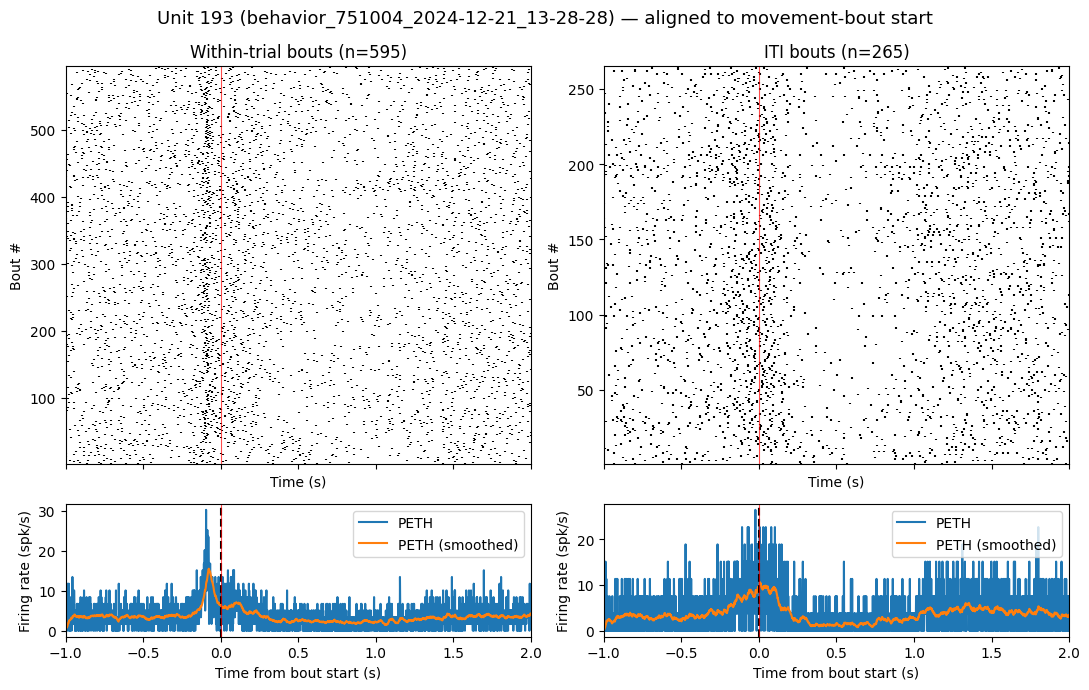

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import (
    make_rp_and_events, compute_psth, smooth_vector, plot_psth
)

# ---- parameters ----
GAP_THRESHOLD_S    = 0.5
ITI_MIN_POST_CUE_S = 2.0
ITI_MIN_PRE_NEXT_S = 1.0
GO_RESPONSE_WINDOW_S = 2.0
PRE, POST = 1.0, 2.0
BIN_SIZE  = 0.001
SMOOTH_SIGMA = 0.025

# ---- annotate bouts in movs ----
movs_annot = annotate_movement_bouts(movs, gap_threshold_s=GAP_THRESHOLD_S)

# ---- bout start times (first movement of each movement-bout) ----
bout_rows = movs_annot[movs_annot["mov_bout_start"]].copy()
bout_rows = bout_rows.sort_values("start_time").reset_index(drop=True)

# classify each bout: within-trial (go_responsive) vs ITI
go_cues = np.sort(trials["goCue_start_time_in_session"].dropna().to_numpy())

t = bout_rows["start_time"].to_numpy()
prev_idx = np.searchsorted(go_cues, t, side="right") - 1
next_idx = prev_idx + 1
has_prev = prev_idx >= 0
has_next = next_idx < len(go_cues)

dt_prev = np.full(len(t), np.nan)
dt_next = np.full(len(t), np.nan)
dt_prev[has_prev] = t[has_prev] - go_cues[prev_idx[has_prev]]
dt_next[has_next] = go_cues[next_idx[has_next]] - t[has_next]

bout_rows["dt_prev_cue"] = dt_prev
bout_rows["dt_next_cue"] = dt_next

go_resp_mask = has_prev & (dt_prev >= 0) & (dt_prev <= GO_RESPONSE_WINDOW_S)
iti_mask     = (has_prev & has_next &
                (dt_prev > ITI_MIN_POST_CUE_S) &
                (dt_next > ITI_MIN_PRE_NEXT_S))

go_resp_bouts = bout_rows[go_resp_mask].reset_index(drop=True)
iti_bouts     = bout_rows[iti_mask].reset_index(drop=True)

print(f"Movement-bouts total: {len(bout_rows)}")
print(f"  go_responsive: {len(go_resp_bouts)}")
print(f"  ITI:           {len(iti_bouts)}")


# ---- helper: build raster+PSTH aligned to arbitrary event times ----
def raster_for_event_times(spikes, event_times, pre, post, bin_size):
    """
    Use make_rp_and_events with synthetic 'trials' = one per event.
    Each event is treated as its own trial aligned at t=0.
    """
    event_times = np.asarray(event_times, dtype=float)
    n = len(event_times)
    trials_synth = list(range(n))
    # single align channel; sort order = trial order (already chronological)
    event_dicts = {"event": dict(zip(trials_synth, event_times))}

    rp, events = make_rp_and_events(
        spikes=spikes,
        trials=trials_synth,
        event_dicts=event_dicts,
        events_to_plot=["event"],
        align_by="event",
        sort_by="event",
        pre=pre,
        post=post,
        bin_size=bin_size,
    )
    return rp, events


def plot_raster_psth(rp, title, ax_raster, ax_psth):
    rp.plot_raster(ax=ax_raster, spike_color="black")
    ax_raster.axvline(0, color="red", lw=0.8, alpha=0.7)
    ax_raster.set_title(title)
    ax_raster.set_ylabel("Bout #")

    psth, _ = compute_psth(rp.raster, bin_size=rp.bin_size)
    psth_sm = smooth_vector(psth, bin_size=rp.bin_size, sigma=SMOOTH_SIGMA)
    plot_psth(rp.bins, psth, psth_sm, ax=ax_psth, label="PETH")
    ax_psth.axvline(0, color="red", lw=0.8, alpha=0.7)
    ax_psth.set_xlabel("Time from bout start (s)")


# ---- build and plot ----
rp_gr, _ = raster_for_event_times(spikes, go_resp_bouts["start_time"].to_numpy(),
                                  PRE, POST, BIN_SIZE)
rp_it, _ = raster_for_event_times(spikes, iti_bouts["start_time"].to_numpy(),
                                  PRE, POST, BIN_SIZE)

fig, axes = plt.subplots(
    2, 2, figsize=(11, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

plot_raster_psth(rp_gr, f"Within-trial bouts (n={len(go_resp_bouts)})",
                 axes[0, 0], axes[1, 0])
plot_raster_psth(rp_it, f"ITI bouts (n={len(iti_bouts)})",
                 axes[0, 1], axes[1, 1])

plt.suptitle(f"Unit {int(unit_id)} ({session}) — aligned to movement-bout start",
             fontsize=13)
plt.tight_layout()
plt.show()

Population heatmap: 103/103 units (dropped 0 for missing baseline or NaN peth)


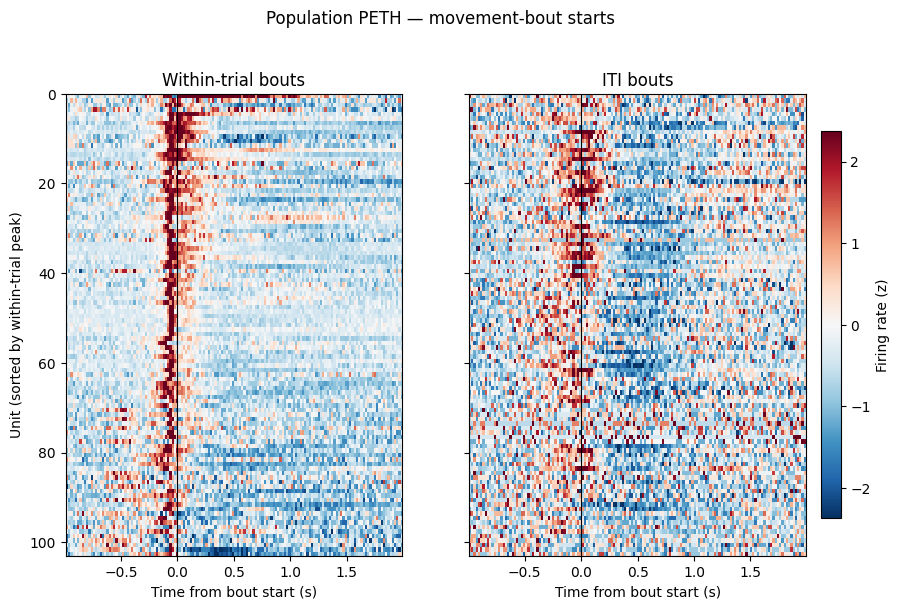

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- params ----
PRE, POST = 1.0, 2.0
BIN_SIZE = 0.02           # 20 ms bins for population heatmap (faster than 1 ms)
BASELINE_WIN = (-1.0, 0.0)
GAP_THRESHOLD_S = 0.5
ITI_MIN_POST_CUE_S = 2.0
ITI_MIN_PRE_NEXT_S = 1.0
GO_RESPONSE_WINDOW_S = 2.0

bins = np.arange(-PRE, POST + BIN_SIZE, BIN_SIZE)
bin_centers = bins[:-1] + BIN_SIZE / 2
n_bins = len(bin_centers)


def get_session_bout_times(data, gap_threshold_s=GAP_THRESHOLD_S):
    """Return (go_resp_starts, iti_starts) using movement-defined bouts."""
    movs_s   = data["movs"]
    trials_s = data["trials"]

    movs_annot = annotate_movement_bouts(movs_s, gap_threshold_s=gap_threshold_s)
    bout_rows = (movs_annot[movs_annot["mov_bout_start"]]
                 .sort_values("start_time").reset_index(drop=True))

    go_cues = np.sort(trials_s["goCue_start_time_in_session"].dropna().to_numpy())
    t = bout_rows["start_time"].to_numpy()
    prev_idx = np.searchsorted(go_cues, t, side="right") - 1
    next_idx = prev_idx + 1
    has_prev = prev_idx >= 0
    has_next = next_idx < len(go_cues)

    dt_prev = np.full(len(t), np.nan)
    dt_next = np.full(len(t), np.nan)
    dt_prev[has_prev] = t[has_prev] - go_cues[prev_idx[has_prev]]
    dt_next[has_next] = go_cues[next_idx[has_next]] - t[has_next]

    gr_mask = has_prev & (dt_prev >= 0) & (dt_prev <= GO_RESPONSE_WINDOW_S)
    it_mask = (has_prev & has_next &
               (dt_prev > ITI_MIN_POST_CUE_S) &
               (dt_next > ITI_MIN_PRE_NEXT_S))

    return t[gr_mask], t[it_mask]


def peth_for_unit(spikes, event_times, bins):
    """Mean firing rate (Hz) across events in each bin."""
    if len(event_times) == 0:
        return np.full(len(bins) - 1, np.nan)
    spikes = np.sort(spikes)
    counts = np.zeros(len(bins) - 1)
    for t0 in event_times:
        idx = np.searchsorted(spikes, [t0 + bins[0], t0 + bins[-1]])
        rel = spikes[idx[0]:idx[1]] - t0
        c, _ = np.histogram(rel, bins=bins)
        counts += c
    return counts / (len(event_times) * BIN_SIZE)  # Hz


# ---- loop over units ----
peth_gr_list, peth_it_list, unit_labels = [], [], []

session_data_cache = session_data_cache if "session_data_cache" in dir() else {}
session_bout_cache = {}

for u in units_with_spikes.itertuples(index=False):
    sess_u = u.session

    if sess_u not in session_data_cache:
        sdir = find_session_dir(sess_u, roots=base_dirs)
        session_data_cache[sess_u] = load_intermediate_data(sdir)
    if sess_u not in session_bout_cache:
        session_bout_cache[sess_u] = get_session_bout_times(session_data_cache[sess_u])

    gr_t, it_t = session_bout_cache[sess_u]

    evnts = session_data_cache[sess_u]["events"]
    offset = evnts.loc[evnts["event"] == "goCue_start_time",
                       "raw_timestamps"].iloc[0]
    spk = np.asarray(u.spike_times, dtype=float) - offset

    peth_gr_list.append(peth_for_unit(spk, gr_t, bins))
    peth_it_list.append(peth_for_unit(spk, it_t, bins))
    unit_labels.append((sess_u, u.unit_id))

peth_gr = np.array(peth_gr_list)  # (n_units, n_bins)
peth_it = np.array(peth_it_list)


# ---- z-score each unit using its own pre-event baseline per condition ----
def zscore_peth(peth, bin_centers, baseline_win):
    mask = (bin_centers >= baseline_win[0]) & (bin_centers < baseline_win[1])
    mu = peth[:, mask].mean(axis=1, keepdims=True)
    sd = peth[:, mask].std(axis=1, keepdims=True)
    sd[sd == 0] = np.nan  # avoid div-by-zero; rows will become nan
    return (peth - mu) / sd

z_gr = zscore_peth(peth_gr, bin_centers, BASELINE_WIN)
z_it = zscore_peth(peth_it, bin_centers, BASELINE_WIN)


# ---- sort by peak response magnitude in go_responsive post-0 window ----
post_mask = bin_centers >= 0
# use signed peak (most extreme deviation, positive or negative) so direction shows
def signed_peak(z, mask):
    seg = z[:, mask]
    pos = np.nanmax(seg, axis=1)
    neg = np.nanmin(seg, axis=1)
    return np.where(np.abs(pos) >= np.abs(neg), pos, neg)

peak_gr = signed_peak(z_gr, post_mask)

valid = np.isfinite(peak_gr) & np.all(np.isfinite(z_gr), axis=1) & np.all(np.isfinite(z_it), axis=1)
order = np.argsort(-peak_gr[valid])  # descending: strongest positive at top
z_gr_sorted = z_gr[valid][order]
z_it_sorted = z_it[valid][order]
n_valid = valid.sum()

print(f"Population heatmap: {n_valid}/{len(unit_labels)} units "
      f"(dropped {len(unit_labels) - n_valid} for missing baseline or NaN peth)")


# ---- plot ----
vmax = np.nanpercentile(np.abs(np.stack([z_gr_sorted, z_it_sorted])), 98)
vmin = -vmax

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

for ax, Z, title in [(axes[0], z_gr_sorted, "Within-trial bouts"),
                      (axes[1], z_it_sorted, "ITI bouts")]:
    im = ax.imshow(Z, aspect="auto", cmap="RdBu_r",
                   vmin=vmin, vmax=vmax,
                   extent=[bin_centers[0], bin_centers[-1], n_valid, 0],
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Time from bout start (s)")
    ax.set_title(title)

axes[0].set_ylabel("Unit (sorted by within-trial peak)")
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Firing rate (z)")
plt.suptitle("Population PETH — movement-bout starts", y=1.02)
plt.show()

Population heatmap: 103/103 units (dropped 0 for missing baseline or NaN peth)


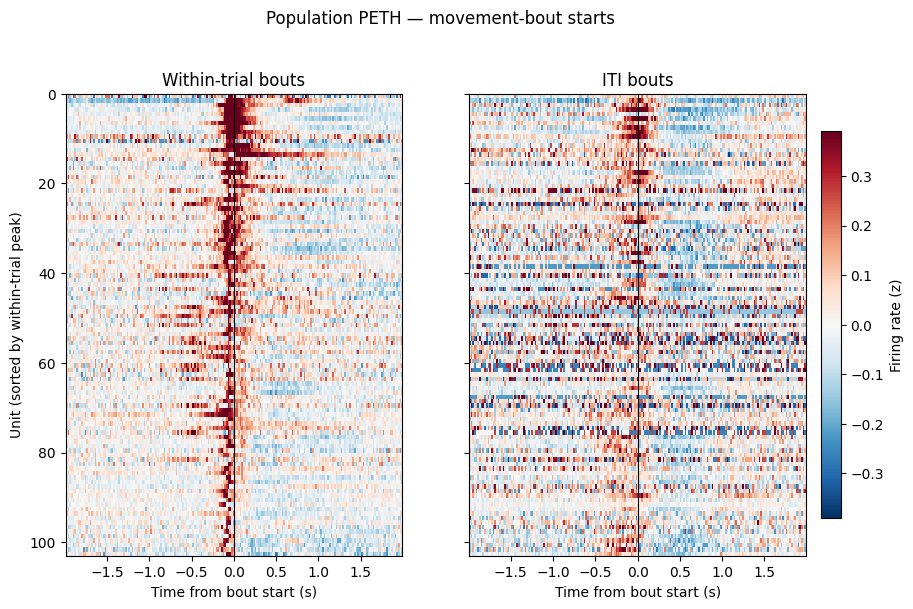

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- params ----
PRE, POST = 2.0, 2.0
BIN_SIZE = 0.02           # 20 ms bins for population heatmap (faster than 1 ms)
BASELINE_WIN = (-1.0, 0.0)
GAP_THRESHOLD_S = 0.5
ITI_MIN_POST_CUE_S = 2.0
ITI_MIN_PRE_NEXT_S = 1.0
GO_RESPONSE_WINDOW_S = 2.0

bins = np.arange(-PRE, POST + BIN_SIZE, BIN_SIZE)
bin_centers = bins[:-1] + BIN_SIZE / 2
n_bins = len(bin_centers)


def get_session_bout_times(data, gap_threshold_s=GAP_THRESHOLD_S):
    """Return (go_resp_starts, iti_starts) using movement-defined bouts."""
    movs_s   = data["movs"]
    trials_s = data["trials"]

    movs_annot = annotate_movement_bouts(movs_s, gap_threshold_s=gap_threshold_s)
    bout_rows = (movs_annot[movs_annot["mov_bout_start"]]
                 .sort_values("start_time").reset_index(drop=True))

    go_cues = np.sort(trials_s["goCue_start_time_in_session"].dropna().to_numpy())
    t = bout_rows["start_time"].to_numpy()
    prev_idx = np.searchsorted(go_cues, t, side="right") - 1
    next_idx = prev_idx + 1
    has_prev = prev_idx >= 0
    has_next = next_idx < len(go_cues)

    dt_prev = np.full(len(t), np.nan)
    dt_next = np.full(len(t), np.nan)
    dt_prev[has_prev] = t[has_prev] - go_cues[prev_idx[has_prev]]
    dt_next[has_next] = go_cues[next_idx[has_next]] - t[has_next]

    gr_mask = has_prev & (dt_prev >= 0) & (dt_prev <= GO_RESPONSE_WINDOW_S)
    it_mask = (has_prev & has_next &
               (dt_prev > ITI_MIN_POST_CUE_S) &
               (dt_next > ITI_MIN_PRE_NEXT_S))

    return t[gr_mask], t[it_mask]


def peth_for_unit(spikes, event_times, bins):
    """Mean firing rate (Hz) across events in each bin."""
    if len(event_times) == 0:
        return np.full(len(bins) - 1, np.nan)
    spikes = np.sort(spikes)
    counts = np.zeros(len(bins) - 1)
    for t0 in event_times:
        idx = np.searchsorted(spikes, [t0 + bins[0], t0 + bins[-1]])
        rel = spikes[idx[0]:idx[1]] - t0
        c, _ = np.histogram(rel, bins=bins)
        counts += c
    return counts / (len(event_times) * BIN_SIZE)  # Hz


# ---- z-score each unit using its own pre-event baseline per condition ----

def session_wide_stats(spikes, bin_size):
    """Mean and SD of firing rate across session in uniform bins."""
    spikes = np.sort(spikes)
    if len(spikes) < 2:
        return np.nan, np.nan
    edges = np.arange(spikes[0], spikes[-1] + bin_size, bin_size)
    counts, _ = np.histogram(spikes, bins=edges)
    rates = counts / bin_size
    return rates.mean(), rates.std()


# ---- loop over units ----
peth_gr_list, peth_it_list, unit_labels = [], [], []
mu_list, sd_list = [], []

session_data_cache = globals().get("session_data_cache", {})
session_bout_cache = {}

for u in units_with_spikes.itertuples(index=False):
    sess_u = u.session

    if sess_u not in session_data_cache:
        sdir = find_session_dir(sess_u, roots=base_dirs)
        session_data_cache[sess_u] = load_intermediate_data(sdir)
    if sess_u not in session_bout_cache:
        session_bout_cache[sess_u] = get_session_bout_times(session_data_cache[sess_u])

    gr_t, it_t = session_bout_cache[sess_u]

    evnts = session_data_cache[sess_u]["events"]
    offset = evnts.loc[evnts["event"] == "goCue_start_time",
                       "raw_timestamps"].iloc[0]
    spk = np.asarray(u.spike_times, dtype=float) - offset

    peth_gr_list.append(peth_for_unit(spk, gr_t, bins))
    peth_it_list.append(peth_for_unit(spk, it_t, bins))
    mu, sd = session_wide_stats(spk, BIN_SIZE)
    mu_list.append(mu)
    sd_list.append(sd)
    unit_labels.append((sess_u, u.unit_id))

peth_gr = np.array(peth_gr_list)
peth_it = np.array(peth_it_list)
mu_arr  = np.array(mu_list)[:, None]
sd_arr  = np.array(sd_list)[:, None]
sd_arr  = np.where(sd_arr == 0, np.nan, sd_arr)

z_gr = (peth_gr - mu_arr) / sd_arr
z_it = (peth_it - mu_arr) / sd_arr


# ---- sort by peak response magnitude in go_responsive post-0 window ----
post_mask = bin_centers >= 0
# use signed peak (most extreme deviation, positive or negative) so direction shows
def signed_peak(z, mask):
    seg = z[:, mask]
    pos = np.nanmax(seg, axis=1)
    neg = np.nanmin(seg, axis=1)
    return np.where(np.abs(pos) >= np.abs(neg), pos, neg)

peak_gr = signed_peak(z_gr, post_mask)

valid = np.isfinite(peak_gr) & np.all(np.isfinite(z_gr), axis=1) & np.all(np.isfinite(z_it), axis=1)
order = np.argsort(-peak_gr[valid])  # descending: strongest positive at top
z_gr_sorted = z_gr[valid][order]
z_it_sorted = z_it[valid][order]
n_valid = valid.sum()

print(f"Population heatmap: {n_valid}/{len(unit_labels)} units "
      f"(dropped {len(unit_labels) - n_valid} for missing baseline or NaN peth)")


# ---- plot ----
vmax = np.nanpercentile(np.abs(np.stack([z_gr_sorted, z_it_sorted])), 98)
vmin = -vmax

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

for ax, Z, title in [(axes[0], z_gr_sorted, "Within-trial bouts"),
                      (axes[1], z_it_sorted, "ITI bouts")]:
    im = ax.imshow(Z, aspect="auto", cmap="RdBu_r",
                   vmin=vmin, vmax=vmax,
                   extent=[bin_centers[0], bin_centers[-1], n_valid, 0],
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Time from bout start (s)")
    ax.set_title(title)

axes[0].set_ylabel("Unit (sorted by within-trial peak)")
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Firing rate (z)")
plt.suptitle("Population PETH — movement-bout starts", y=1.02)
plt.show()

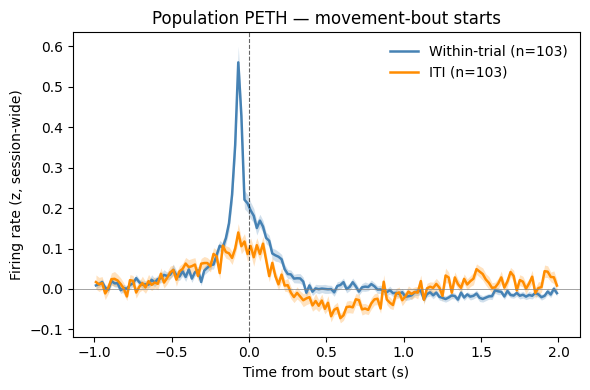

In [90]:
# ---- overlay: population-averaged PETH per condition ----
gr_mean = np.nanmean(z_gr_sorted, axis=0)
gr_sem  = np.nanstd(z_gr_sorted, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(z_gr_sorted), axis=0))

it_mean = np.nanmean(z_it_sorted, axis=0)
it_sem  = np.nanstd(z_it_sorted, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(z_it_sorted), axis=0))

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(bin_centers, gr_mean, color="steelblue", lw=1.8, label=f"Within-trial (n={n_valid})")
ax.fill_between(bin_centers, gr_mean - gr_sem, gr_mean + gr_sem,
                color="steelblue", alpha=0.25, linewidth=0)

ax.plot(bin_centers, it_mean, color="darkorange", lw=1.8, label=f"ITI (n={n_valid})")
ax.fill_between(bin_centers, it_mean - it_sem, it_mean + it_sem,
                color="darkorange", alpha=0.25, linewidth=0)

ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.6)
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Time from bout start (s)")
ax.set_ylabel("Firing rate (z, session-wide)")
ax.set_title("Population PETH — movement-bout starts")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

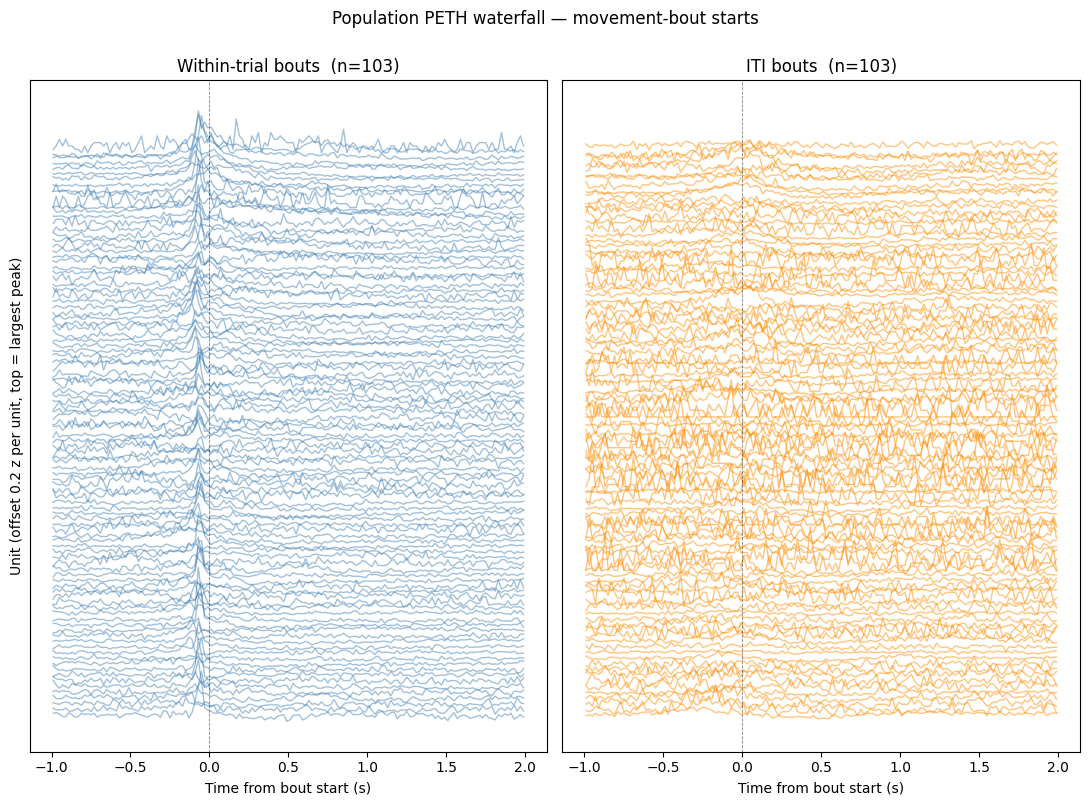

In [99]:
# ---- waterfall: stacked per-unit PETHs, same order as heatmap ----
OFFSET = 0.2   # vertical offset per unit (in z units); tune for visual density
LW = 1
ALPHA = 0.5

fig, axes = plt.subplots(1, 2, figsize=(11, 8), sharex=True, sharey=True)

for ax, Z, title, color in [
    (axes[0], z_gr_sorted, "Within-trial bouts", "steelblue"),
    (axes[1], z_it_sorted, "ITI bouts",          "darkorange"),
]:
    n = Z.shape[0]
    for i in range(n):
        # offset: top unit (i=0) sits highest
        y = Z[i] + (n - 1 - i) * OFFSET
        ax.plot(bin_centers, y, color=color, lw=LW, alpha=ALPHA)

    ax.axvline(0, color="black", lw=0.6, ls="--", alpha=0.5)
    ax.set_xlabel("Time from bout start (s)")
    ax.set_title(f"{title}  (n={n})")

axes[0].set_ylabel(f"Unit (offset {OFFSET} z per unit, top = largest peak)")
# hide y-ticks since they're arbitrary
for ax in axes:
    ax.set_yticks([])

plt.suptitle("Population PETH waterfall — movement-bout starts", y=1.00)
plt.tight_layout()
plt.show()

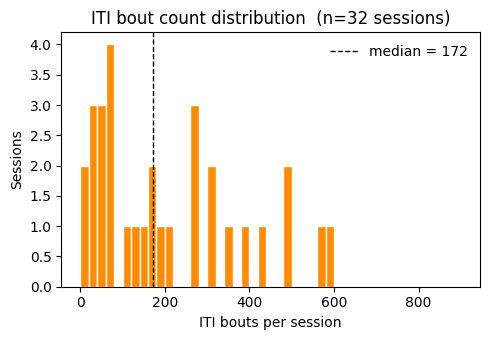

min: 15, median: 172, max: 912, total: 7277


In [104]:
# ---- distribution of ITI bout counts per session ----
iti_counts = {sess: len(bout_times[1])  # (gr_times, iti_times) tuple
              for sess, bout_times in session_bout_cache.items()}

counts = np.array(list(iti_counts.values()))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(counts, bins=np.arange(0, counts.max() + 5, 20),
        color="darkorange", edgecolor="white")
ax.axvline(np.median(counts), color="black", ls="--", lw=1,
           label=f"median = {int(np.median(counts))}")
ax.set_xlabel("ITI bouts per session")
ax.set_ylabel("Sessions")
ax.set_title(f"ITI bout count distribution  (n={len(counts)} sessions)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"min: {counts.min()}, median: {int(np.median(counts))}, "
      f"max: {counts.max()}, total: {counts.sum()}")

Sessions with >100 bouts in both: 19/32
Population heatmap: 54/103 units (dropped 49 for missing baseline or NaN peth)


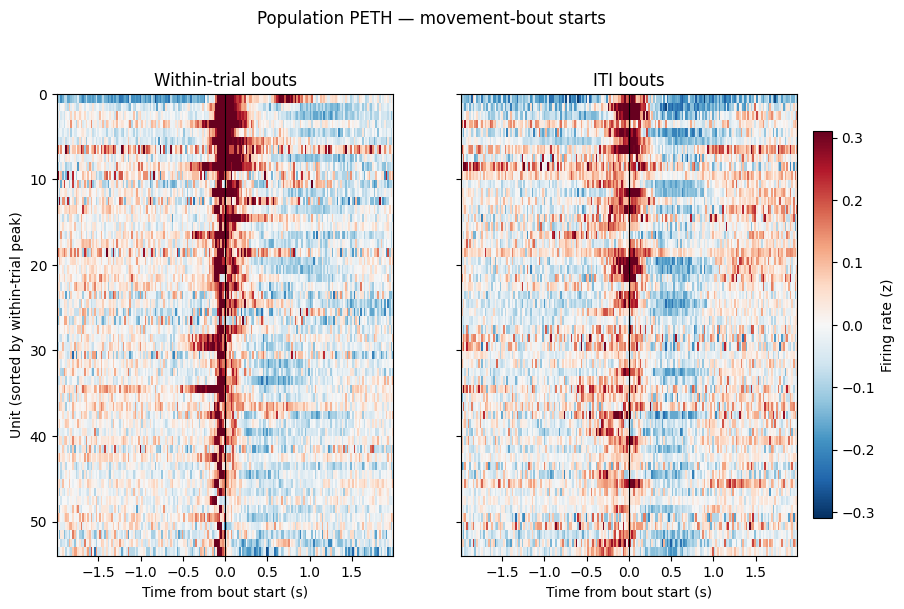

In [ ]:
# ---- filter to sessions with >100 bouts in both conditions ----
MIN_BOUTS = 100

good_sessions = {
    sess for sess, (gr_t, it_t) in session_bout_cache.items()
    if len(gr_t) > MIN_BOUTS and len(it_t) > MIN_BOUTS
}
print(f"Sessions with >{MIN_BOUTS} bouts in both: "
      f"{len(good_sessions)}/{len(session_bout_cache)}")

session_arr = np.array([lbl[0] for lbl in unit_labels])
session_mask = np.isin(session_arr, list(good_sessions))





import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- params ----
PRE, POST = 2.0, 2.0
BIN_SIZE = 0.02           # 20 ms bins for population heatmap (faster than 1 ms)
BASELINE_WIN = (-1.0, 0.0)
GAP_THRESHOLD_S = 0.5
ITI_MIN_POST_CUE_S = 2.0
ITI_MIN_PRE_NEXT_S = 1.0
GO_RESPONSE_WINDOW_S = 2.0

bins = np.arange(-PRE, POST + BIN_SIZE, BIN_SIZE)
bin_centers = bins[:-1] + BIN_SIZE / 2
n_bins = len(bin_centers)


def get_session_bout_times(data, gap_threshold_s=GAP_THRESHOLD_S):
    """Return (go_resp_starts, iti_starts) using movement-defined bouts."""
    movs_s   = data["movs"]
    trials_s = data["trials"]

    movs_annot = annotate_movement_bouts(movs_s, gap_threshold_s=gap_threshold_s)
    bout_rows = (movs_annot[movs_annot["mov_bout_start"]]
                 .sort_values("start_time").reset_index(drop=True))

    go_cues = np.sort(trials_s["goCue_start_time_in_session"].dropna().to_numpy())
    t = bout_rows["start_time"].to_numpy()
    prev_idx = np.searchsorted(go_cues, t, side="right") - 1
    next_idx = prev_idx + 1
    has_prev = prev_idx >= 0
    has_next = next_idx < len(go_cues)

    dt_prev = np.full(len(t), np.nan)
    dt_next = np.full(len(t), np.nan)
    dt_prev[has_prev] = t[has_prev] - go_cues[prev_idx[has_prev]]
    dt_next[has_next] = go_cues[next_idx[has_next]] - t[has_next]

    gr_mask = has_prev & (dt_prev >= 0) & (dt_prev <= GO_RESPONSE_WINDOW_S)
    it_mask = (has_prev & has_next &
               (dt_prev > ITI_MIN_POST_CUE_S) &
               (dt_next > ITI_MIN_PRE_NEXT_S))

    return t[gr_mask], t[it_mask]


def peth_for_unit(spikes, event_times, bins):
    """Mean firing rate (Hz) across events in each bin."""
    if len(event_times) == 0:
        return np.full(len(bins) - 1, np.nan)
    spikes = np.sort(spikes)
    counts = np.zeros(len(bins) - 1)
    for t0 in event_times:
        idx = np.searchsorted(spikes, [t0 + bins[0], t0 + bins[-1]])
        rel = spikes[idx[0]:idx[1]] - t0
        c, _ = np.histogram(rel, bins=bins)
        counts += c
    return counts / (len(event_times) * BIN_SIZE)  # Hz


# ---- z-score each unit using its own pre-event baseline per condition ----

def session_wide_stats(spikes, bin_size):
    """Mean and SD of firing rate across session in uniform bins."""
    spikes = np.sort(spikes)
    if len(spikes) < 2:
        return np.nan, np.nan
    edges = np.arange(spikes[0], spikes[-1] + bin_size, bin_size)
    counts, _ = np.histogram(spikes, bins=edges)
    rates = counts / bin_size
    return rates.mean(), rates.std()


# ---- loop over units ----
peth_gr_list, peth_it_list, unit_labels = [], [], []
mu_list, sd_list = [], []

session_data_cache = globals().get("session_data_cache", {})
session_bout_cache = {}

for u in units_with_spikes.itertuples(index=False):
    sess_u = u.session

    if sess_u not in session_data_cache:
        sdir = find_session_dir(sess_u, roots=base_dirs)
        session_data_cache[sess_u] = load_intermediate_data(sdir)
    if sess_u not in session_bout_cache:
        session_bout_cache[sess_u] = get_session_bout_times(session_data_cache[sess_u])

    gr_t, it_t = session_bout_cache[sess_u]

    evnts = session_data_cache[sess_u]["events"]
    offset = evnts.loc[evnts["event"] == "goCue_start_time",
                       "raw_timestamps"].iloc[0]
    spk = np.asarray(u.spike_times, dtype=float) - offset

    peth_gr_list.append(peth_for_unit(spk, gr_t, bins))
    peth_it_list.append(peth_for_unit(spk, it_t, bins))
    mu, sd = session_wide_stats(spk, BIN_SIZE)
    mu_list.append(mu)
    sd_list.append(sd)
    unit_labels.append((sess_u, u.unit_id))

peth_gr = np.array(peth_gr_list)
peth_it = np.array(peth_it_list)
mu_arr  = np.array(mu_list)[:, None]
sd_arr  = np.array(sd_list)[:, None]
sd_arr  = np.where(sd_arr == 0, np.nan, sd_arr)

z_gr = (peth_gr - mu_arr) / sd_arr
z_it = (peth_it - mu_arr) / sd_arr




# ---- sort by peak response magnitude in go_responsive post-0 window ----
post_mask = bin_centers >= 0
# use signed peak (most extreme deviation, positive or negative) so direction shows
def signed_peak(z, mask):
    seg = z[:, mask]
    pos = np.nanmax(seg, axis=1)
    neg = np.nanmin(seg, axis=1)
    return np.where(np.abs(pos) >= np.abs(neg), pos, neg)

peak_gr = signed_peak(z_gr, post_mask)

valid = (session_mask &
         np.isfinite(peak_gr) &
         np.all(np.isfinite(z_gr), axis=1) &
         np.all(np.isfinite(z_it), axis=1))
order = np.argsort(-peak_gr[valid])  # descending: strongest positive at top
z_gr_sorted = z_gr[valid][order]
z_it_sorted = z_it[valid][order]
n_valid = valid.sum()

print(f"Population heatmap: {n_valid}/{len(unit_labels)} units "
      f"(dropped {len(unit_labels) - n_valid} for missing baseline or NaN peth)")


# ---- plot ----
vmax = np.nanpercentile(np.abs(np.stack([z_gr_sorted, z_it_sorted])), 98)
vmin = -vmax

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

for ax, Z, title in [(axes[0], z_gr_sorted, "Within-trial bouts"),
                      (axes[1], z_it_sorted, "ITI bouts")]:
    im = ax.imshow(Z, aspect="auto", cmap="RdBu_r",
                   vmin=vmin, vmax=vmax,
                   extent=[bin_centers[0], bin_centers[-1], n_valid, 0],
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Time from bout start (s)")
    ax.set_title(title)

axes[0].set_ylabel("Unit (sorted by within-trial peak)")
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Firing rate (z)")
plt.suptitle("Population PETH — movement-bout starts", y=1.02)
plt.show()

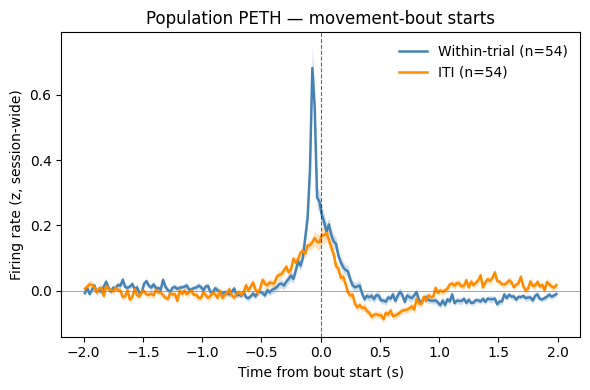

In [107]:
# ---- overlay: population-averaged PETH per condition ----
gr_mean = np.nanmean(z_gr_sorted, axis=0)
gr_sem  = np.nanstd(z_gr_sorted, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(z_gr_sorted), axis=0))

it_mean = np.nanmean(z_it_sorted, axis=0)
it_sem  = np.nanstd(z_it_sorted, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(z_it_sorted), axis=0))

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(bin_centers, gr_mean, color="steelblue", lw=1.8, label=f"Within-trial (n={n_valid})")
ax.fill_between(bin_centers, gr_mean - gr_sem, gr_mean + gr_sem,
                color="steelblue", alpha=0.25, linewidth=0)

ax.plot(bin_centers, it_mean, color="darkorange", lw=1.8, label=f"ITI (n={n_valid})")
ax.fill_between(bin_centers, it_mean - it_sem, it_mean + it_sem,
                color="darkorange", alpha=0.25, linewidth=0)

ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.6)
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Time from bout start (s)")
ax.set_ylabel("Firing rate (z, session-wide)")
ax.set_title("Population PETH — movement-bout starts")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Sessions with >100 bouts in both: 19/32


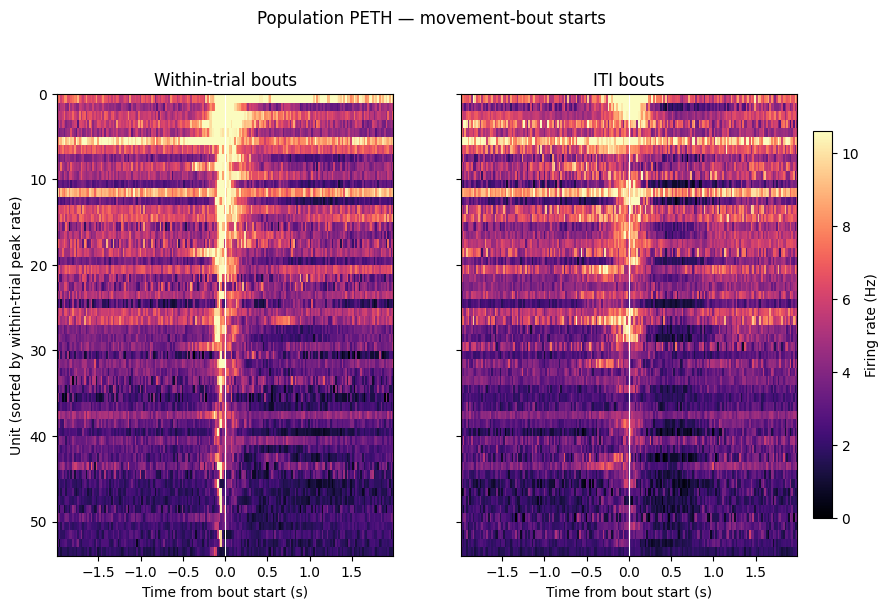

In [108]:
# ---- filter to sessions with >100 bouts in both conditions ----
MIN_BOUTS = 100

good_sessions = {
    sess for sess, (gr_t, it_t) in session_bout_cache.items()
    if len(gr_t) > MIN_BOUTS and len(it_t) > MIN_BOUTS
}
print(f"Sessions with >{MIN_BOUTS} bouts in both: "
      f"{len(good_sessions)}/{len(session_bout_cache)}")

session_arr = np.array([lbl[0] for lbl in unit_labels])
session_mask = np.isin(session_arr, list(good_sessions))





import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- params ----
PRE, POST = 2.0, 2.0
BIN_SIZE = 0.02           # 20 ms bins for population heatmap (faster than 1 ms)
BASELINE_WIN = (-1.0, 0.0)
GAP_THRESHOLD_S = 0.5
ITI_MIN_POST_CUE_S = 2.0
ITI_MIN_PRE_NEXT_S = 1.0
GO_RESPONSE_WINDOW_S = 2.0

bins = np.arange(-PRE, POST + BIN_SIZE, BIN_SIZE)
bin_centers = bins[:-1] + BIN_SIZE / 2
n_bins = len(bin_centers)


def get_session_bout_times(data, gap_threshold_s=GAP_THRESHOLD_S):
    """Return (go_resp_starts, iti_starts) using movement-defined bouts."""
    movs_s   = data["movs"]
    trials_s = data["trials"]

    movs_annot = annotate_movement_bouts(movs_s, gap_threshold_s=gap_threshold_s)
    bout_rows = (movs_annot[movs_annot["mov_bout_start"]]
                 .sort_values("start_time").reset_index(drop=True))

    go_cues = np.sort(trials_s["goCue_start_time_in_session"].dropna().to_numpy())
    t = bout_rows["start_time"].to_numpy()
    prev_idx = np.searchsorted(go_cues, t, side="right") - 1
    next_idx = prev_idx + 1
    has_prev = prev_idx >= 0
    has_next = next_idx < len(go_cues)

    dt_prev = np.full(len(t), np.nan)
    dt_next = np.full(len(t), np.nan)
    dt_prev[has_prev] = t[has_prev] - go_cues[prev_idx[has_prev]]
    dt_next[has_next] = go_cues[next_idx[has_next]] - t[has_next]

    gr_mask = has_prev & (dt_prev >= 0) & (dt_prev <= GO_RESPONSE_WINDOW_S)
    it_mask = (has_prev & has_next &
               (dt_prev > ITI_MIN_POST_CUE_S) &
               (dt_next > ITI_MIN_PRE_NEXT_S))

    return t[gr_mask], t[it_mask]


def peth_for_unit(spikes, event_times, bins):
    """Mean firing rate (Hz) across events in each bin."""
    if len(event_times) == 0:
        return np.full(len(bins) - 1, np.nan)
    spikes = np.sort(spikes)
    counts = np.zeros(len(bins) - 1)
    for t0 in event_times:
        idx = np.searchsorted(spikes, [t0 + bins[0], t0 + bins[-1]])
        rel = spikes[idx[0]:idx[1]] - t0
        c, _ = np.histogram(rel, bins=bins)
        counts += c
    return counts / (len(event_times) * BIN_SIZE)  # Hz


# ---- z-score each unit using its own pre-event baseline per condition ----

def session_wide_stats(spikes, bin_size):
    """Mean and SD of firing rate across session in uniform bins."""
    spikes = np.sort(spikes)
    if len(spikes) < 2:
        return np.nan, np.nan
    edges = np.arange(spikes[0], spikes[-1] + bin_size, bin_size)
    counts, _ = np.histogram(spikes, bins=edges)
    rates = counts / bin_size
    return rates.mean(), rates.std()


# ---- loop over units ----
peth_gr_list, peth_it_list, unit_labels = [], [], []
mu_list, sd_list = [], []

session_data_cache = globals().get("session_data_cache", {})
session_bout_cache = {}

for u in units_with_spikes.itertuples(index=False):
    sess_u = u.session

    if sess_u not in session_data_cache:
        sdir = find_session_dir(sess_u, roots=base_dirs)
        session_data_cache[sess_u] = load_intermediate_data(sdir)
    if sess_u not in session_bout_cache:
        session_bout_cache[sess_u] = get_session_bout_times(session_data_cache[sess_u])

    gr_t, it_t = session_bout_cache[sess_u]

    evnts = session_data_cache[sess_u]["events"]
    offset = evnts.loc[evnts["event"] == "goCue_start_time",
                       "raw_timestamps"].iloc[0]
    spk = np.asarray(u.spike_times, dtype=float) - offset

    peth_gr_list.append(peth_for_unit(spk, gr_t, bins))
    peth_it_list.append(peth_for_unit(spk, it_t, bins))
    mu, sd = session_wide_stats(spk, BIN_SIZE)
    mu_list.append(mu)
    sd_list.append(sd)
    unit_labels.append((sess_u, u.unit_id))

peth_gr = np.array(peth_gr_list)
peth_it = np.array(peth_it_list)
mu_arr  = np.array(mu_list)[:, None]
sd_arr  = np.array(sd_list)[:, None]
sd_arr  = np.where(sd_arr == 0, np.nan, sd_arr)

z_gr = (peth_gr - mu_arr) / sd_arr
z_it = (peth_it - mu_arr) / sd_arr




# ---- sort by peak response magnitude in go_responsive post-0 window ----
post_mask = bin_centers >= 0
# use signed peak (most extreme deviation, positive or negative) so direction shows
def signed_peak(z, mask):
    seg = z[:, mask]
    pos = np.nanmax(seg, axis=1)
    neg = np.nanmin(seg, axis=1)
    return np.where(np.abs(pos) >= np.abs(neg), pos, neg)

# remove the z_gr / z_it computation entirely, or keep them unused
# replace downstream references:

peak_gr = signed_peak(peth_gr, post_mask)  # was z_gr

valid = (session_mask &
         np.isfinite(peak_gr) &
         np.all(np.isfinite(peth_gr), axis=1) &
         np.all(np.isfinite(peth_it), axis=1))
order = np.argsort(-peak_gr[valid])
gr_sorted = peth_gr[valid][order]
it_sorted = peth_it[valid][order]

# ---- plot ----
vmax = np.nanpercentile(np.stack([gr_sorted, it_sorted]), 98)

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
for ax, Z, title in [(axes[0], gr_sorted, "Within-trial bouts"),
                      (axes[1], it_sorted, "ITI bouts")]:
    im = ax.imshow(Z, aspect="auto", cmap="magma",
                   vmin=0, vmax=vmax,
                   extent=[bin_centers[0], bin_centers[-1], n_valid, 0],
                   interpolation="nearest")
    ax.axvline(0, color="white", lw=0.8)
    ax.set_xlabel("Time from bout start (s)")
    ax.set_title(title)

axes[0].set_ylabel("Unit (sorted by within-trial peak rate)")
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Firing rate (Hz)")
plt.suptitle("Population PETH — movement-bout starts", y=1.02)
plt.show()

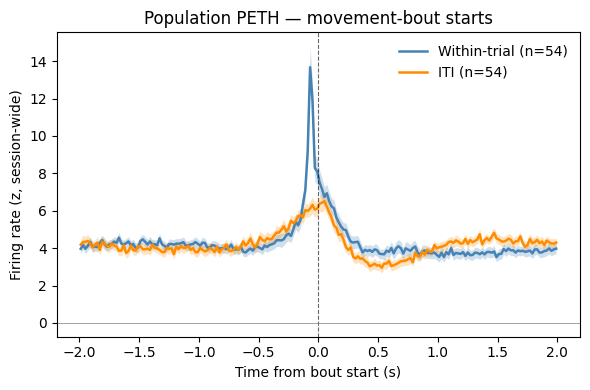

In [109]:
# ---- overlay: population-averaged PETH per condition ----
gr_mean = np.nanmean(gr_sorted, axis=0)
gr_sem  = np.nanstd(gr_sorted, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(gr_sorted), axis=0))

it_mean = np.nanmean(it_sorted, axis=0)
it_sem  = np.nanstd(it_sorted, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(it_sorted), axis=0))

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(bin_centers, gr_mean, color="steelblue", lw=1.8, label=f"Within-trial (n={n_valid})")
ax.fill_between(bin_centers, gr_mean - gr_sem, gr_mean + gr_sem,
                color="steelblue", alpha=0.25, linewidth=0)

ax.plot(bin_centers, it_mean, color="darkorange", lw=1.8, label=f"ITI (n={n_valid})")
ax.fill_between(bin_centers, it_mean - it_sem, it_mean + it_sem,
                color="darkorange", alpha=0.25, linewidth=0)

ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.6)
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Time from bout start (s)")
ax.set_ylabel("Firing rate (z, session-wide)")
ax.set_title("Population PETH — movement-bout starts")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

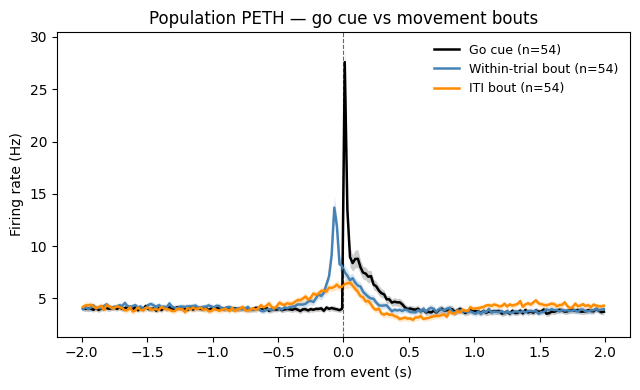

In [110]:
# ---- compute go-cue-aligned PETH for the same units ----
peth_cue_list = []

for u, (sess_u, _uid) in zip(units_with_spikes.itertuples(index=False), unit_labels):
    data = session_data_cache[sess_u]
    trials_s = data["trials"]
    evnts = data["events"]

    offset = evnts.loc[evnts["event"] == "goCue_start_time",
                       "raw_timestamps"].iloc[0]
    spk = np.asarray(u.spike_times, dtype=float) - offset

    cue_times = trials_s["goCue_start_time_in_session"].dropna().to_numpy()
    peth_cue_list.append(peth_for_unit(spk, cue_times, bins))

peth_cue = np.array(peth_cue_list)

# use the same validity mask and order as the bout heatmap
cue_sorted = peth_cue[valid][order]

# ---- overlay: three conditions ----
def mean_sem(Z):
    mean = np.nanmean(Z, axis=0)
    n    = np.sum(~np.isnan(Z), axis=0)
    sem  = np.nanstd(Z, axis=0, ddof=1) / np.sqrt(n)
    return mean, sem

gr_mean,  gr_sem  = mean_sem(gr_sorted)
it_mean,  it_sem  = mean_sem(it_sorted)
cue_mean, cue_sem = mean_sem(cue_sorted)

fig, ax = plt.subplots(figsize=(6.5, 4))

for mean, sem, color, label in [
    (cue_mean, cue_sem, "black",      f"Go cue (n={n_valid})"),
    (gr_mean,  gr_sem,  "steelblue",  f"Within-trial bout (n={n_valid})"),
    (it_mean,  it_sem,  "darkorange", f"ITI bout (n={n_valid})"),
]:
    ax.plot(bin_centers, mean, color=color, lw=1.8, label=label)
    ax.fill_between(bin_centers, mean - sem, mean + sem,
                    color=color, alpha=0.2, linewidth=0)

ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.6)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title("Population PETH — go cue vs movement bouts")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

analysis of bouts based on lick bouts

In [23]:


# ---- Parameters ----
GO_RESPONSE_WINDOW_S = 2.0   # go_responsive: first in-trial movement within this window post-cue
ITI_MIN_POST_CUE_S   = 1.5   # ITI bout must start at least this long after preceding go cue
ITI_MIN_PRE_NEXT_S   = 1.0   # ITI bout must start at least this long before the next go cue

# ---- 1. Go cue times, sorted ----
go_cues = np.sort(trials["goCue_start_time_in_session"].dropna().to_numpy())

# ---- 2. Bout starts from licks ----
bout_starts_df = licks.loc[licks["bout_start"] == True, ["timestamps", "trial", "bout_number"]].copy()
bout_starts_df = bout_starts_df.sort_values("timestamps").reset_index(drop=True)
bout_times = bout_starts_df["timestamps"].to_numpy()

# For each bout start, find preceding and next go cue
prev_idx = np.searchsorted(go_cues, bout_times, side="right") - 1
next_idx = prev_idx + 1

has_prev = prev_idx >= 0
has_next = next_idx < len(go_cues)

time_since_prev_cue = np.full(len(bout_times), np.nan)
time_until_next_cue = np.full(len(bout_times), np.nan)
time_since_prev_cue[has_prev] = bout_times[has_prev] - go_cues[prev_idx[has_prev]]
time_until_next_cue[has_next] = go_cues[next_idx[has_next]] - bout_times[has_next]

bout_starts_df["time_since_prev_cue"] = time_since_prev_cue
bout_starts_df["time_until_next_cue"] = time_until_next_cue

print("Bout start timing relative to go cues:")
print(f"  n bouts: {len(bout_starts_df)}")
print(f"  time since prev cue — median: {np.nanmedian(time_since_prev_cue):.2f}s, "
      f"p10: {np.nanpercentile(time_since_prev_cue, 10):.2f}s, "
      f"p90: {np.nanpercentile(time_since_prev_cue, 90):.2f}s")
print(f"  fraction within 2s of prev cue: {np.nanmean(time_since_prev_cue < 2.0):.2%}")

# ---- 3. go_responsive: first movement in trial, within window, from movs frame ----
first_movs = movs[movs["movement_number_in_trial"] == 1].copy()
# movs already has goCue_start_time_in_session and movement_latency_from_go
go_responsive = first_movs[
    (first_movs["movement_latency_from_go"] >= 0) &
    (first_movs["movement_latency_from_go"] <= GO_RESPONSE_WINDOW_S)
].copy()
go_responsive["class"] = "go_responsive"

print(f"\ngo_responsive: {len(go_responsive)} movements "
      f"({len(go_responsive)}/{len(first_movs)} first-in-trial movements within {GO_RESPONSE_WINDOW_S}s)")

# ---- 4. ITI: bout starts in licks, guarded on both sides ----
iti_mask = (
    has_prev & has_next &
    (time_since_prev_cue > ITI_MIN_POST_CUE_S) &
    (time_until_next_cue > ITI_MIN_PRE_NEXT_S)
)

iti_bouts = bout_starts_df[iti_mask].copy()
iti_bouts["class"] = "ITI"
print(f"ITI: {len(iti_bouts)} bout starts "
      f"(>{ITI_MIN_POST_CUE_S}s post-cue, >{ITI_MIN_PRE_NEXT_S}s pre-next-cue)")

# ---- 5. Excluded counts (sanity) ----
n_excluded_bouts = len(bout_starts_df) - len(iti_bouts)
n_excluded_first_movs = len(first_movs) - len(go_responsive)
print(f"\nExcluded: {n_excluded_first_movs} first-in-trial movs outside window, "
      f"{n_excluded_bouts} bout starts not meeting ITI criteria")

Bout start timing relative to go cues:
  n bouts: 403
  time since prev cue — median: 0.20s, p10: 0.09s, p90: 1.98s
  fraction within 2s of prev cue: 90.07%

go_responsive: 369 movements (369/369 first-in-trial movements within 2.0s)
ITI: 22 bout starts (>1.5s post-cue, >1.0s pre-next-cue)

Excluded: 0 first-in-trial movs outside window, 381 bout starts not meeting ITI criteria


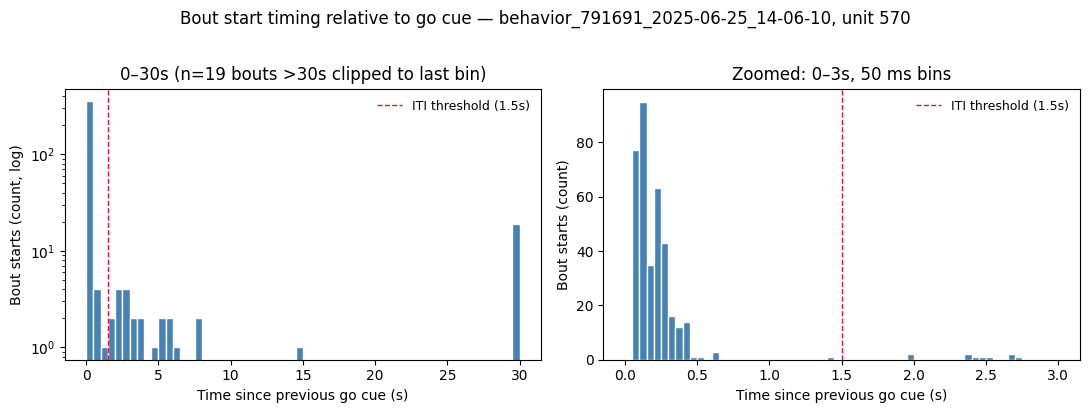

In [25]:
import matplotlib.pyplot as plt
import numpy as np

valid = time_since_prev_cue[~np.isnan(time_since_prev_cue)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: 0–30s, log y to see the ITI tail
ax = axes[0]
ax.hist(np.clip(valid, 0, 30), bins=np.arange(0, 30.5, 0.5),
        color="steelblue", edgecolor="white")
ax.axvline(ITI_MIN_POST_CUE_S, color="crimson", linestyle="--", lw=1,
           label=f"ITI threshold ({ITI_MIN_POST_CUE_S}s)")
ax.set_yscale("log")
ax.set_xlabel("Time since previous go cue (s)")
ax.set_ylabel("Bout starts (count, log)")
ax.set_title(f"0–30s (n={(valid > 30).sum()} bouts >30s clipped to last bin)")
ax.legend(frameon=False, fontsize=9)

# Right: zoomed 0–3s, linear, 50 ms bins
ax = axes[1]
ax.hist(valid[valid <= 3.0], bins=np.arange(0, 3.05, 0.05),
        color="steelblue", edgecolor="white")
ax.axvline(ITI_MIN_POST_CUE_S, color="crimson", linestyle="--", lw=1,
           label=f"ITI threshold ({ITI_MIN_POST_CUE_S}s)")
ax.set_xlabel("Time since previous go cue (s)")
ax.set_ylabel("Bout starts (count)")
ax.set_title("Zoomed: 0–3s, 50 ms bins")
ax.legend(frameon=False, fontsize=9)

fig.suptitle(f"Bout start timing relative to go cue — {session}, unit {int(unit_id)}", y=1.02)
fig.tight_layout()
plt.show()

In [26]:

BASELINE_WIN = (-1.0, 0.0)
RESPONSE_WIN = (0.0, 0.2)

def count_spikes(spikes, event_times, window):
    starts = event_times + window[0]
    ends   = event_times + window[1]
    return (np.searchsorted(spikes, ends,   side="left") -
            np.searchsorted(spikes, starts, side="left"))

spikes = np.sort(spikes)  # make sure sorted

# --- go_responsive: align to first tongue movement onset ---
gr_t = go_responsive["start_time"].to_numpy()
gr = pd.DataFrame({
    "class": "go_responsive",
    "event_time": gr_t,
    "baseline_rate_hz": count_spikes(spikes, gr_t, BASELINE_WIN) / (BASELINE_WIN[1] - BASELINE_WIN[0]),
    "spike_rate_hz":    count_spikes(spikes, gr_t, RESPONSE_WIN) / (RESPONSE_WIN[1] - RESPONSE_WIN[0]),
})

# --- ITI: align to bout start ---
it_t = iti_bouts["timestamps"].to_numpy()
it = pd.DataFrame({
    "class": "ITI",
    "event_time": it_t,
    "baseline_rate_hz": count_spikes(spikes, it_t, BASELINE_WIN) / (BASELINE_WIN[1] - BASELINE_WIN[0]),
    "spike_rate_hz":    count_spikes(spikes, it_t, RESPONSE_WIN) / (RESPONSE_WIN[1] - RESPONSE_WIN[0]),
})

counts = pd.concat([gr, it], ignore_index=True)
counts["delta_hz"] = counts["spike_rate_hz"] - counts["baseline_rate_hz"]

print(counts.groupby("class")[["baseline_rate_hz", "spike_rate_hz", "delta_hz"]]
            .agg(["mean", "std", "count"]))

              baseline_rate_hz                 spike_rate_hz                  \
                          mean       std count          mean       std count   
class                                                                          
ITI                   5.772727  2.990968    22      5.909091  4.264014    22   
go_responsive         5.907859  1.580165   369      9.078591  3.699560   369   

               delta_hz                  
                   mean       std count  
class                                    
ITI            0.136364  4.257156    22  
go_responsive  3.170732  4.573745   369  


Paired units (both classes present): 103 / 103


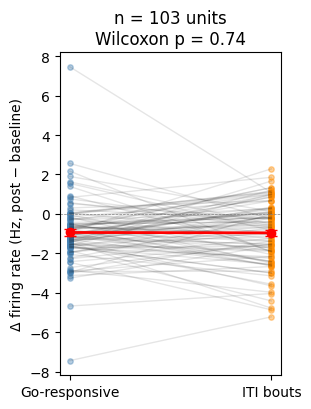

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

BASELINE_WIN = (-0.5, 0.0)
RESPONSE_WIN = (0.0, 0.5)
ITI_MIN_POST_CUE_S = 2.0
ITI_MIN_PRE_NEXT_S = 0.5
GO_RESPONSE_WINDOW_S = 1.0


def count_spikes(spikes, event_times, window):
    starts = event_times + window[0]
    ends   = event_times + window[1]
    return (np.searchsorted(spikes, ends,   side="left") -
            np.searchsorted(spikes, starts, side="left"))


def get_session_event_times(session_data):
    """Return (go_resp_times, iti_times) for one session."""
    movs   = session_data["movs"]
    licks  = session_data["licks"]
    trials = session_data["trials"]

    # go_responsive: first in-trial movement within window after cue
    first_movs = movs[movs["movement_number_in_trial"] == 1]
    gr = first_movs[
        (first_movs["movement_latency_from_go"] >= 0) &
        (first_movs["movement_latency_from_go"] <= GO_RESPONSE_WINDOW_S)
    ]
    gr_times = gr["start_time"].to_numpy()

    # ITI: bout starts guarded on both sides by go cues
    go_cues = np.sort(trials["goCue_start_time_in_session"].dropna().to_numpy())
    bs = licks.loc[licks["bout_start"] == True, "timestamps"].to_numpy()
    bs = np.sort(bs)

    prev_idx = np.searchsorted(go_cues, bs, side="right") - 1
    next_idx = prev_idx + 1
    has_prev = prev_idx >= 0
    has_next = next_idx < len(go_cues)

    dt_prev = np.full(len(bs), np.nan)
    dt_next = np.full(len(bs), np.nan)
    dt_prev[has_prev] = bs[has_prev] - go_cues[prev_idx[has_prev]]
    dt_next[has_next] = go_cues[next_idx[has_next]] - bs[has_next]

    iti_mask = (has_prev & has_next &
                (dt_prev > ITI_MIN_POST_CUE_S) &
                (dt_next > ITI_MIN_PRE_NEXT_S))
    iti_times = bs[iti_mask]

    return gr_times, iti_times


def compute_unit_bout_counts(spikes, session, unit_id, gr_times, iti_times):
    pre_dur  = BASELINE_WIN[1] - BASELINE_WIN[0]
    post_dur = RESPONSE_WIN[1] - RESPONSE_WIN[0]
    spikes = np.sort(spikes)

    rows = []
    for class_label, evt in [("go_responsive", gr_times), ("ITI", iti_times)]:
        if len(evt) == 0:
            continue
        base = count_spikes(spikes, evt, BASELINE_WIN) / pre_dur
        post = count_spikes(spikes, evt, RESPONSE_WIN) / post_dur
        rows.append(pd.DataFrame({
            "session": session,
            "unit_id": unit_id,
            "class": class_label,
            "event_time": evt,
            "baseline_rate_hz": base,
            "spike_rate_hz": post,
            "delta_hz": post - base,
        }))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


# ---- loop over units, caching session-level event times ----
session_events_cache = {}
session_data_cache   = {}
all_bout_counts = []

for u in units_with_spikes.itertuples(index=False):
    session = u.session

    if session not in session_events_cache:
        # load session data once (adapt to however you load it)
        sdir = find_session_dir(session, roots=base_dirs)
        session_data_cache[session] = load_intermediate_data(sdir)
        session_events_cache[session] = get_session_event_times(session_data_cache[session])

    gr_times, iti_times = session_events_cache[session]

    # session offset to convert absolute spikes → session time
    evnts = session_data_cache[session]["events"]
    session_offset = evnts.loc[evnts["event"] == "goCue_start_time",
                               "raw_timestamps"].iloc[0]
    spikes = np.asarray(u.spike_times, dtype=float) - session_offset

    uc = compute_unit_bout_counts(spikes, session, u.unit_id, gr_times, iti_times)
    if len(uc):
        all_bout_counts.append(uc)

bout_counts_df = pd.concat(all_bout_counts, ignore_index=True)

# ---- per-unit mean delta_hz, paired across classes ----
unit_mean = (bout_counts_df
             .groupby(["session", "unit_id", "class"])["delta_hz"]
             .mean()
             .unstack("class"))

# keep units with both classes present
paired = unit_mean.dropna(subset=["go_responsive", "ITI"])
print(f"Paired units (both classes present): {len(paired)} / {len(unit_mean)}")

gr_vals = paired["go_responsive"].to_numpy()
it_vals = paired["ITI"].to_numpy()

# stats
d = gr_vals - it_vals
d_nz = d[d != 0]
stat_p = wilcoxon(d_nz).pvalue if len(d_nz) else np.nan

# ---- plot ----
fig, ax = plt.subplots(figsize=(3.2, 4.2))
x_pos = np.array([0.0, 1.0])

for g, i in zip(gr_vals, it_vals):
    ax.plot(x_pos, [g, i], "k-", alpha=0.1, lw=1)

ax.scatter(np.zeros_like(gr_vals), gr_vals, s=15, alpha=0.4, color="steelblue")
ax.scatter(np.ones_like(it_vals),  it_vals, s=15, alpha=0.4, color="darkorange")

means = [gr_vals.mean(), it_vals.mean()]
sems  = [gr_vals.std(ddof=1) / np.sqrt(len(gr_vals)),
         it_vals.std(ddof=1) / np.sqrt(len(it_vals))]
ax.errorbar(x_pos, means, sems, fmt="o", color="red",
            capsize=4, lw=2, zorder=5)
ax.plot(x_pos, means, "r-", lw=2)

ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_xticks(x_pos)
ax.set_xticklabels(["Go-responsive", "ITI bouts"])
ax.set_ylabel("Δ firing rate (Hz, post − baseline)")
ax.set_title(f"n = {len(paired)} units\nWilcoxon p = {stat_p:.2g}")
plt.tight_layout()
plt.show()

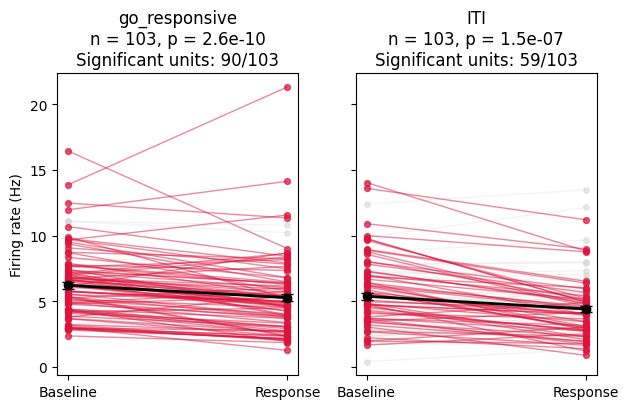

In [41]:
# ---- separate paired plots: baseline vs response, per class ----
# per-unit mean rates (for plotting)
unit_rates = (bout_counts_df
              .groupby(["session", "unit_id", "class"])[["baseline_rate_hz", "spike_rate_hz"]]
              .mean()
              .reset_index())

# per-unit Wilcoxon across trials (for significance counts)
def summarize_unit(g):
    pre  = g["baseline_rate_hz"].to_numpy()
    post = g["spike_rate_hz"].to_numpy()
    d = post - pre
    d = d[np.isfinite(d) & (d != 0)]
    p = wilcoxon(d, alternative="two-sided").pvalue if len(d) else np.nan
    return pd.Series({"p": p})

unit_stats = (bout_counts_df
              .groupby(["session", "unit_id", "class"], sort=False)
              .apply(summarize_unit)
              .reset_index())

# merge significance into unit_rates for easy per-unit coloring
unit_rates = unit_rates.merge(unit_stats, on=["session", "unit_id", "class"], how="left")
unit_rates["sig"] = unit_rates["p"] < 0.05

SIG_COLOR    = "crimson"
NONSIG_COLOR = "lightgray"

fig, axes = plt.subplots(1, 2, figsize=(6.4, 4.2), sharey=True)

for ax, cls in [(axes[0], "go_responsive"), (axes[1], "ITI")]:
    sub = unit_rates[unit_rates["class"] == cls]
    y_pre  = sub["baseline_rate_hz"].to_numpy()
    y_post = sub["spike_rate_hz"].to_numpy()
    sig    = sub["sig"].to_numpy()

    # group-level wilcoxon on unit means
    d = y_post - y_pre
    d_nz = d[d != 0]
    p_group = wilcoxon(d_nz).pvalue if len(d_nz) else np.nan

    n_sig = int(sig.sum())
    n_tot = int(np.isfinite(sub["p"]).sum())

    x_pos = np.array([0.0, 1.0])

    # draw non-sig first (behind), then sig on top
    for yp, yo, s in zip(y_pre, y_post, sig):
        c = SIG_COLOR if s else NONSIG_COLOR
        a = 0.5 if s else 0.25
        z = 2 if s else 1
        ax.plot(x_pos, [yp, yo], "-", color=c, alpha=a, lw=1, zorder=z)

    # scatter non-sig then sig so sig sits on top
    ns = ~sig
    ax.scatter(np.zeros(ns.sum()), y_pre[ns],  s=15, alpha=0.5,
               color=NONSIG_COLOR, zorder=1)
    ax.scatter(np.ones(ns.sum()),  y_post[ns], s=15, alpha=0.5,
               color=NONSIG_COLOR, zorder=1)
    ax.scatter(np.zeros(sig.sum()), y_pre[sig],  s=18, alpha=0.7,
               color=SIG_COLOR, zorder=3)
    ax.scatter(np.ones(sig.sum()),  y_post[sig], s=18, alpha=0.7,
               color=SIG_COLOR, zorder=3)

    means = [y_pre.mean(), y_post.mean()]
    sems  = [y_pre.std(ddof=1) / np.sqrt(len(y_pre)),
             y_post.std(ddof=1) / np.sqrt(len(y_post))]
    ax.errorbar(x_pos, means, sems, fmt="o", color="black",
                capsize=4, lw=2, zorder=5)
    ax.plot(x_pos, means, "k-", lw=2, zorder=5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(["Baseline", "Response"])
    ax.set_title(f"{cls}\nn = {len(sub)}, p = {p_group:.2g}\n"
                 f"Significant units: {n_sig}/{n_tot}")

axes[0].set_ylabel("Firing rate (Hz)")
plt.tight_layout()
plt.show()

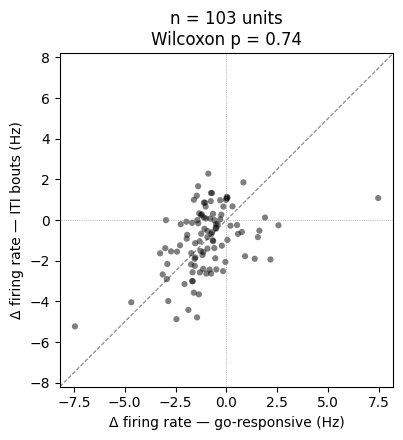

In [42]:
# ---- scatter: go_responsive vs ITI delta_hz, per unit ----
fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.scatter(gr_vals, it_vals, s=20, alpha=0.5, color="black",
           edgecolor="none")

# unity line
lo = min(gr_vals.min(), it_vals.min())
hi = max(gr_vals.max(), it_vals.max())
pad = 0.05 * (hi - lo)
lims = (lo - pad, hi + pad)
ax.plot(lims, lims, "k--", lw=0.8, alpha=0.5)
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.axvline(0, color="gray", lw=0.5, ls=":")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("Δ firing rate — go-responsive (Hz)")
ax.set_ylabel("Δ firing rate — ITI bouts (Hz)")
ax.set_title(f"n = {len(paired)} units\nWilcoxon p = {stat_p:.2g}")
plt.tight_layout()
plt.show()

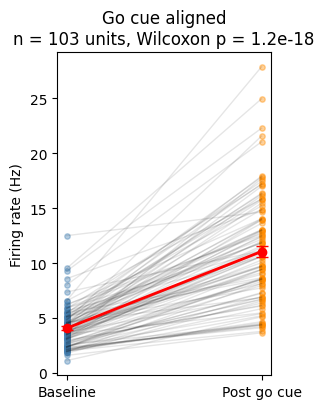

Units with increased FR post-cue: 103/103
Units with decreased FR post-cue: 0/103


In [29]:
# ---- sanity check: recompute go-cue-aligned counts with same method ----
all_gocue_counts = []

for u in units_with_spikes.itertuples(index=False):
    session = u.session

    if session not in session_data_cache:
        sdir = find_session_dir(session, roots=base_dirs)
        session_data_cache[session] = load_intermediate_data(sdir)

    data = session_data_cache[session]
    trials_df = data["trials"]
    evnts = data["events"]

    session_offset = evnts.loc[evnts["event"] == "goCue_start_time",
                               "raw_timestamps"].iloc[0]
    spikes = np.sort(np.asarray(u.spike_times, dtype=float) - session_offset)

    cue_times = trials_df["goCue_start_time_in_session"].dropna().to_numpy()
    if len(cue_times) == 0:
        continue

    pre_dur  = BASELINE_WIN[1] - BASELINE_WIN[0]
    post_dur = RESPONSE_WIN[1] - RESPONSE_WIN[0]
    base = count_spikes(spikes, cue_times, BASELINE_WIN) / pre_dur
    post = count_spikes(spikes, cue_times, RESPONSE_WIN) / post_dur

    all_gocue_counts.append(pd.DataFrame({
        "session": session,
        "unit_id": u.unit_id,
        "baseline_rate_hz": base,
        "spike_rate_hz": post,
        "delta_hz": post - base,
    }))

gocue_df = pd.concat(all_gocue_counts, ignore_index=True)

# ---- per-unit means ----
unit_gocue = (gocue_df
              .groupby(["session", "unit_id"])[["baseline_rate_hz", "spike_rate_hz"]]
              .mean()
              .reset_index())

y_pre  = unit_gocue["baseline_rate_hz"].to_numpy()
y_post = unit_gocue["spike_rate_hz"].to_numpy()

d = y_post - y_pre
d_nz = d[d != 0]
p_cue = wilcoxon(d_nz).pvalue if len(d_nz) else np.nan

# ---- plot ----
fig, ax = plt.subplots(figsize=(3.2, 4.2))
x_pos = np.array([0.0, 1.0])

for yp, yo in zip(y_pre, y_post):
    ax.plot(x_pos, [yp, yo], "k-", alpha=0.1, lw=1)

ax.scatter(np.zeros_like(y_pre),  y_pre,  s=15, alpha=0.4, color="steelblue")
ax.scatter(np.ones_like(y_post),  y_post, s=15, alpha=0.4, color="darkorange")

means = [y_pre.mean(), y_post.mean()]
sems  = [y_pre.std(ddof=1) / np.sqrt(len(y_pre)),
         y_post.std(ddof=1) / np.sqrt(len(y_post))]
ax.errorbar(x_pos, means, sems, fmt="o", color="red",
            capsize=4, lw=2, zorder=5)
ax.plot(x_pos, means, "r-", lw=2)

ax.set_xticks(x_pos)
ax.set_xticklabels(["Baseline", "Post go cue"])
ax.set_ylabel("Firing rate (Hz)")
ax.set_title(f"Go cue aligned\nn = {len(unit_gocue)} units, "
             f"Wilcoxon p = {p_cue:.2g}")
plt.tight_layout()
plt.show()

# ---- quick numeric diff vs reference analysis ----
n_increase = (d > 0).sum()
n_decrease = (d < 0).sum()
print(f"Units with increased FR post-cue: {n_increase}/{len(d)}")
print(f"Units with decreased FR post-cue: {n_decrease}/{len(d)}")

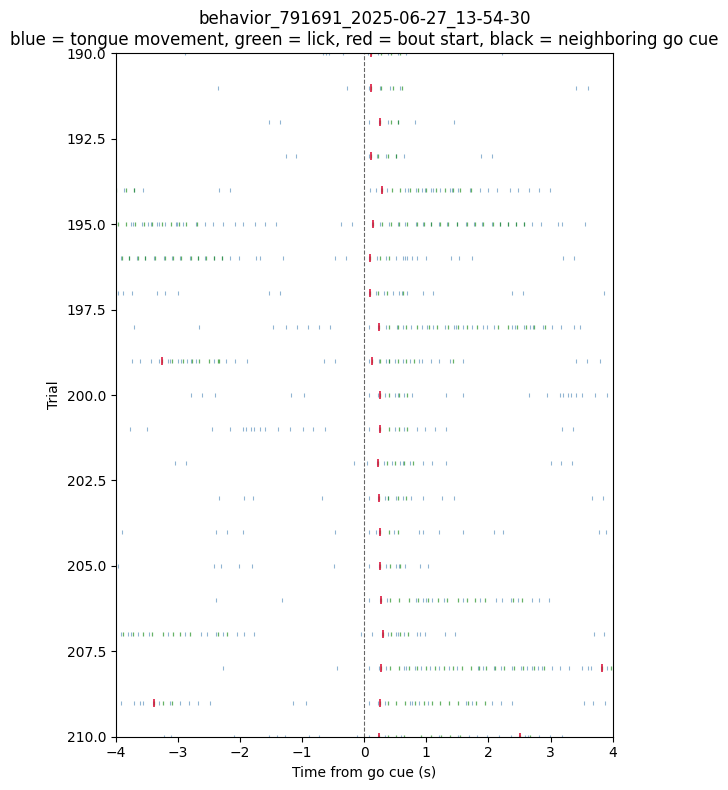

In [49]:
# ---- event raster around go cues: one session, one panel ----
data = session_data_cache[session]
movs_s   = data["movs"]
licks_s  = data["licks"]
trials_s = data["trials"]

WIN = (-4.0, 4.0)

cue_times_series = trials_s.set_index("trial")["goCue_start_time_in_session"].dropna()
cue_times_arr = np.sort(cue_times_series.to_numpy())

mov_starts  = np.sort(movs_s["start_time"].dropna().to_numpy())
lick_times  = np.sort(licks_s["timestamps"].dropna().to_numpy())
bout_starts = np.sort(
    licks_s.loc[licks_s["bout_start"] == True, "timestamps"].to_numpy()
)

fig, ax = plt.subplots(figsize=(6, 8))

for trial_id, t0 in cue_times_series.items():
    m = mov_starts[(mov_starts  >= t0 + WIN[0]) & (mov_starts  <= t0 + WIN[1])] - t0
    l = lick_times[(lick_times  >= t0 + WIN[0]) & (lick_times  <= t0 + WIN[1])] - t0
    b = bout_starts[(bout_starts >= t0 + WIN[0]) & (bout_starts <= t0 + WIN[1])] - t0
    c = cue_times_arr[(cue_times_arr >= t0 + WIN[0]) & (cue_times_arr <= t0 + WIN[1])] - t0
    c = c[c != 0]

    if len(m):
        ax.scatter(m, np.full_like(m, trial_id), s=6, color="steelblue",
                   alpha=0.6, marker="|", linewidths=0.8)
    if len(l):
        ax.scatter(l, np.full_like(l, trial_id), s=10, color="green",
                   alpha=0.6, marker="|", linewidths=0.9)
    if len(b):
        ax.scatter(b, np.full_like(b, trial_id), s=32, color="crimson",
                   alpha=0.9, marker="|", linewidths=1.3)
    if len(c):
        ax.scatter(c, np.full_like(c, trial_id), s=32, color="black",
                   alpha=0.8, marker="|", linewidths=1.3)

ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.6)
ax.set_xlim(WIN)
ax.set_ylim(190,210)
ax.set_xlabel("Time from go cue (s)")
ax.set_ylabel("Trial")
ax.set_title(f"{session}\nblue = tongue movement, green = lick, red = bout start, black = neighboring go cue")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

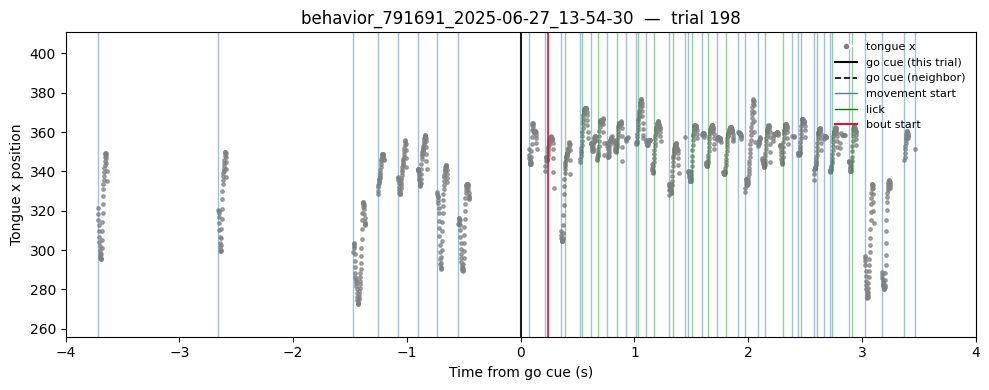

In [50]:
# ---- single-trial timeseries + events: trial 198 ----
TRIAL_ID = 198
WIN = (-4.0, 4.0)

data = session_data_cache[session]
kins_s   = data["kins"]
movs_s   = data["movs"]
licks_s  = data["licks"]
trials_s = data["trials"]

t0 = trials_s.set_index("trial").loc[TRIAL_ID, "goCue_start_time_in_session"]
t_lo, t_hi = t0 + WIN[0], t0 + WIN[1]

# kinematics in window
k = kins_s[(kins_s["time_in_session"] >= t_lo) & (kins_s["time_in_session"] <= t_hi)]
k_t = k["time_in_session"].to_numpy() - t0
k_x = k["x"].to_numpy()

# events in window
mov_starts  = movs_s["start_time"].dropna().to_numpy()
lick_times  = licks_s["timestamps"].dropna().to_numpy()
bout_starts = licks_s.loc[licks_s["bout_start"] == True, "timestamps"].to_numpy()
cue_times   = trials_s["goCue_start_time_in_session"].dropna().to_numpy()

def in_win(arr):
    arr = np.asarray(arr)
    return arr[(arr >= t_lo) & (arr <= t_hi)] - t0

m = in_win(mov_starts)
l = in_win(lick_times)
b = in_win(bout_starts)
c = in_win(cue_times)
c = c[c != 0]  # exclude the current cue

fig, ax = plt.subplots(figsize=(10, 4))

# tongue x position
ax.scatter(k_t, k_x, s=6, color="gray", alpha=0.7, label="tongue x")

# events as vertical lines (full height) with distinct colors
ymin, ymax = ax.get_ylim()
span = ymax - ymin
ax.set_ylim(ymin - 0.1 * span, ymax + 0.25 * span)
ymin, ymax = ax.get_ylim()

for x in m:
    ax.axvline(x, color="steelblue", alpha=0.5, lw=1)
for x in l:
    ax.axvline(x, color="green", alpha=0.4, lw=1)
for x in b:
    ax.axvline(x, color="crimson", alpha=0.8, lw=1.5)
for x in c:
    ax.axvline(x, color="black", alpha=0.7, lw=1.2, ls="--")

# current go cue at 0
ax.axvline(0, color="black", lw=1.5, ls="-", alpha=0.9)

# legend proxies
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=5, label="tongue x"),
    Line2D([0], [0], color="black", lw=1.5, label="go cue (this trial)"),
    Line2D([0], [0], color="black", lw=1.2, ls="--", label="go cue (neighbor)"),
    Line2D([0], [0], color="steelblue", lw=1, label="movement start"),
    Line2D([0], [0], color="green", lw=1, label="lick"),
    Line2D([0], [0], color="crimson", lw=1.5, label="bout start"),
]
ax.legend(handles=legend_elems, loc="upper right", fontsize=8, frameon=False)

ax.set_xlim(WIN)
ax.set_xlabel("Time from go cue (s)")
ax.set_ylabel("Tongue x position")
ax.set_title(f"{session}  —  trial {TRIAL_ID}")
plt.tight_layout()
plt.show()

In [52]:
from aind_dynamic_foraging_behavior_video_analysis.kinematics.video_clip_utils import extract_clips_ffmpeg_after_reencode

def extract_clip_for_movements(movement_ids, kins, video_path, save_dir, pad_s=0.1):
    """
    Extract a video clip spanning a range of movement IDs.

    Parameters
    ----------
    movement_ids : list
        List of movement_ids to span (uses min/max time across all).
    kins : pd.DataFrame
        Session kinematics dataframe (must have 'movement_id' and 'time' columns).
    video_path : str or Path
        Path to the labeled video file.
    save_dir : str or Path
        Directory to save the extracted clip.
    pad_s : float
        Padding in seconds before and after the movement span.
    """
    subset = kins[kins["movement_id"].isin(movement_ids)]
    if subset.empty:
        print(f"No kins data found for movement_ids: {movement_ids}")
        return

    t_start = subset["time"].min() - pad_s
    t_end   = subset["time"].max() + pad_s
    clip_length = t_end - t_start

    mid_str = f"{min(movement_ids)}-{max(movement_ids)}"
    filename_stem = f"movements_{mid_str}"

    extract_clips_ffmpeg_after_reencode(
        input_video_path=video_path,
        timestamps=[t_start],
        clip_length=clip_length,
        output_dir=save_dir,
        filename_stems=[filename_stem]
    )
    print(f"Clip saved: {filename_stem} ({t_start:.3f}s — {t_end:.3f}s, duration={clip_length:.3f}s)")

# ---- extract video clip for all movements in trial 198's ±4 s window ----
VIDEO_PATH = "/root/capsule/data/behavior_791691_2025-06-27_13-54-27_videoprocessed_2025-11-07_21-12-28/pred_outputs/video_preds/labeled_videos/bottom_camera_labeled.mp4"
SAVE_DIR   = "/root/capsule/scratch/movement_clips"

# movements whose start_time falls in the window
mov_win = movs_s[
    (movs_s["start_time"] >= t_lo) &
    (movs_s["start_time"] <= t_hi)
]
movement_ids = mov_win["movement_id"].tolist()
print(f"Found {len(movement_ids)} movements in window: {min(movement_ids)}–{max(movement_ids)}")

extract_clip_for_movements(
    movement_ids=movement_ids,
    kins=kins_s,
    video_path=VIDEO_PATH,
    save_dir=SAVE_DIR,
    pad_s=0.1,
)

Found 35 movements in window: 4758–4792


ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --e

Clip saved to /root/capsule/scratch/movement_clips/movements_4758-4792_1815.151s_to_1822.537s.mp4
Clip saved: movements_4758-4792 (1815.151s — 1822.537s, duration=7.386s)


frame= 3772 fps=0.0 q=-1.0 Lsize=    5171kB time=00:00:07.38 bitrate=5735.4kbits/s speed=23.6x    
video:5127kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.862143%
